# CA 4.2: Brain Tumor Segmentation with U-Net

## Problem definition: Segmentation of gliomas in MRI scans

In this jupyter notebook, we will be doing whole tumor (WT) segmentation. WT includes subregions 1, 2 and 4.



Each pixel on image is labelled as :

- Pixel is part of a tumor area (subregions: 1, 2, 4)
- Pixel is not a part of tumor area (0)

where, 0 - no tumor, 1 - necrotic/core/ non-enhancing, 2 - edema, 4 - enhancing


**Objectivies (What will we learn here?)**
1. Setting up the env
2. Create training, validation and test ids
3. Image pre-processing
4. Performance metrics for semantic segmentation
5. Loss functions for semantic segmentation
6. Building the Unet model
7. Training the model
8. Looking at the learning curve
9. Predicting using the Unet model
10. What next? It is time to play!




## Step 1: Set up the env

Download all the packages needed.

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from tqdm import tqdm

## Step 2: Now let's create the training, validation and test ids.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = Path('/content/drive/MyDrive/brats.zip')
EXTRACT_ROOT = Path('/content/brats_data')

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset zip at: {ZIP_PATH}")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

# Only unzip once per runtime unless the folder is empty.
if not any(EXTRACT_ROOT.iterdir()):
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_ROOT}"

print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_ROOT:", EXTRACT_ROOT)
print("Top-level extracted contents:", os.listdir(EXTRACT_ROOT)[:10])

Mounted at /content/drive
ZIP_PATH: /content/drive/MyDrive/brats.zip
EXTRACT_ROOT: /content/brats_data
Top-level extracted contents: ['BraTS2020_TrainingData', 'BraTS2020_ValidationData']


In [3]:
# Define paths for the Colab-extracted BraTS dataset
DATA_PATH = Path('/content/brats_data')

train_matches = list(DATA_PATH.rglob('MICCAI_BraTS2020_TrainingData'))
valid_matches = list(DATA_PATH.rglob('MICCAI_BraTS2020_ValidationData'))

if not train_matches:
    raise FileNotFoundError(
        f"Could not find MICCAI_BraTS2020_TrainingData under {DATA_PATH}"
    )

if not valid_matches:
    raise FileNotFoundError(
        f"Could not find MICCAI_BraTS2020_ValidationData under {DATA_PATH}"
    )

TRAIN_DATA_PATH = train_matches[0]
VALID_DATA_PATH = valid_matches[0]

print("DATA_PATH:", DATA_PATH)
print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("VALID_DATA_PATH:", VALID_DATA_PATH)

DATA_PATH: /content/brats_data
TRAIN_DATA_PATH: /content/brats_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
VALID_DATA_PATH: /content/brats_data/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData


In [15]:
# Let's create the training, validation and test ids.

train_dir = sorted([
    f.path
    for f in os.scandir(TRAIN_DATA_PATH)
    if f.is_dir() and Path(f.path).name != 'BraTS20_Training_355' # This was bugging out
])

# We will create train, validation and test ids from the train_dir dataset

def list_to_ids(dir: str):
    """
    Will convert the dir paths to ids by parsing the paths.
    dir: string, image dir paths in BRATS
    """
    x = []
    for i in range(0, len(dir)):
        x.append(dir[i].split('/')[-1])
    return x

How to do train-test-split using sklearn: https://www.stackvidhya.com/train-test-split-using-sklearn-in-python/

In [17]:
# Now let's use the defined function

ids = list_to_ids(train_dir)

# Split dataset to create training ids, validation ids and test ids
# Here we have selected the size of test set as 20% which is a common practice.
train_ids, test_ids = train_test_split(ids,test_size=0.2)

# Create validation ids by further splitting the train ids, we again use 20% as size of validation set.
# Validation set is also referred to as tuning set.

train_ids, val_ids = train_test_split(train_ids,test_size=0.2)

In [18]:
# Now looks at the number of patient ids in training, validation and test sets
print(f'There are {len(train_ids)} patient ids in training set')
print(f'There are {len(val_ids)} patient ids in validation set')
print(f'There are {len(test_ids)} patient ids in test set')

There are 235 patient ids in training set
There are 59 patient ids in validation set
There are 74 patient ids in test set


### Understanding the Data Split

We use a common 64-16-20 split resulting in:
- **Training set (236 patients)**: Used to learn the model parameters through backpropagation
- **Validation set (59 patients)**: Used to tune hyperparameters and monitor training progress
- **Test set (74 patients)**: Held out completely - the model never sees this during training

This three-way split helps us:
1. **Train** without overfitting (we monitor validation loss)
2. **Validate** hyperparameter choices without "peeking" at test set
3. **Test** final performance on truly unseen data for an unbiased evaluation

This is standard practice in machine learning to ensure models generalize well to new data.

## Step 3: Let's do some image pre-processing. You have already learnt basics of reading and visualizing nifti images, selecting slices and looking at histograms.

Here, we will look at some pre-processing steps specific to semantic segmentation. It's important to understand that the pro-processing steps could vary depending on the task at hand.


In [19]:
# Let's rewind and remember the type of images available: T1, T1CE, T2, FLAIR and corresponding masks

# We will use the read_patient_niftis module we had learnt in the previous notebook
def read_patient_niftis(patient_id: str,
                        niftis_to_load = ['t1', 't1ce', 't2', 'flair', 'seg'],
                        data_path = TRAIN_DATA_PATH):
    """
    Will read in the images from a single patient and return a dictionary of
    those images with the key as the image type and the value as the nifti object.
    patient_id: string of format '001' through '369', patient ID in BRATS
    niftis_to_load: default is list containing all the types of images that we care about; can sub in another list if desired.
    data_path: default is DATA_PATH specified above with respect to the mounted google drive (in colab)

    Args:
        patient_id (str): Patient ID in BRATS (e.g., 'BraTS20_Training_001').
        niftis_to_load (list): List of image types to load (e.g., ['t1', 't1ce']).
        data_path (str or Path): Path to the dataset.

    Returns:
        dict: Dictionary with keys as image types and values as nifti objects.
    """
    patient_image_dict = {}
    for image in niftis_to_load:
        nii_gz_path = Path(data_path, f'{patient_id}', f'{patient_id}_{image}.nii.gz')
        nii_path = Path(data_path, f'{patient_id}', f'{patient_id}_{image}.nii')

        # Check for the existence of .nii.gz or .nii files
        if nii_gz_path.exists():
            patient_image_dict[image] = nib.load(nii_gz_path)
        elif nii_path.exists():
            patient_image_dict[image] = nib.load(nii_path)
        else:
            raise FileNotFoundError(f"Neither {nii_gz_path} nor {nii_path} found for {patient_id}")
    return patient_image_dict

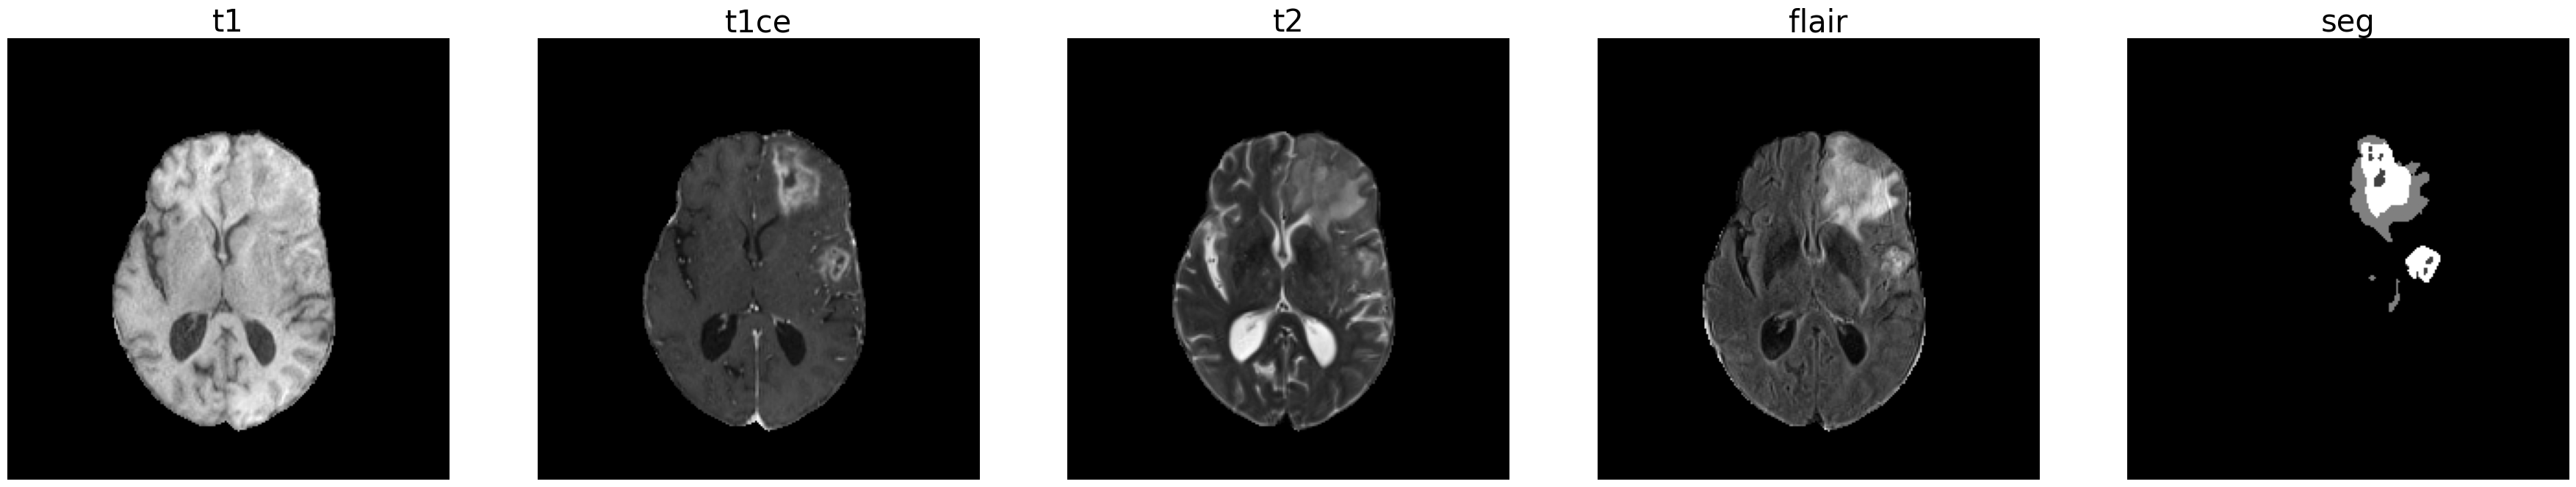

In [20]:
# Let's take a look one of the image and the corresponding segmentation mask from the training set before we proceed
pt_img_dict = read_patient_niftis(train_ids[12])

# Now lets visualize all the images side by side to get a sense of what's happening.
plt.figure(figsize=(45,30)) # specifying the overall grid size
for i, (key, value) in enumerate(pt_img_dict.items()):
    plt.subplot(1, 5, i+1)
    plt.imshow(value._dataobj[:, :, value.shape[-1]//2].T, cmap='gray') # Looks halfway through the volume and transposes the image so that its facing upward.
    plt.axis('off')
    plt.title(key, fontsize=30)
plt.show()

A quick recap on MRI basics: https://my-ms.org/mri_basics.html

In [21]:
# For this semantic segmentation task, we will use T2 images.
# And we will focus on binary or whole tumor (WT) segmentation. In order to do so we will assign the same pixel intensity (1) to the 3 tumor sub regions (1, 2, 4)

def normalize(input_image, input_mask, percentile=0.001, eps=1e-6):
    """
    Normalize the input image between 0 and 1 and prepare the mask for binary segmentation.

    Args:
        input_image: The image to be segmented
        input_mask: The ground truth or segmentation labels
        percentile: Percentile for robust normalization (removes outliers)
        eps: Small epsilon to avoid division by zero

    Returns:
        img_normalized: Normalized image as torch tensor in range [0, 1]
        mask_normalized: Binary mask (0 or 1) as torch tensor
    """
    # Convert input image to a PyTorch tensor if it's not already
    if not isinstance(input_image, torch.Tensor):
        input_image = torch.tensor(input_image, dtype=torch.float32)

    # Ensure the tensor is contiguous before reshaping
    img_array = input_image.contiguous().view(-1)

    # Calculate the min and max based on the percentiles
    min_img = torch.quantile(img_array, percentile)
    max_img = torch.quantile(img_array, 1 - percentile)

    # Normalize the image
    img_normalized = (input_image - min_img) / (max_img - min_img + eps)

    # Ensure the image is in the range [0, 1]
    img_normalized = torch.clamp(img_normalized, 0, 1)

    # Convert image to float tensor if not already
    img_normalized = img_normalized.float()

    # Process the mask: convert all tumor regions (1, 2, 4) to 1, background stays 0
    if not isinstance(input_mask, torch.Tensor):
        input_mask = torch.tensor(input_mask, dtype=torch.int32)
    mask_normalized = torch.where(input_mask >= 1, 1, 0)

    return img_normalized, mask_normalized

In [22]:
# Example usage
# Assuming pt_img_dict['t2'] and pt_img_dict['seg'] are loaded as PyTorch tensors
t2_img = torch.tensor(pt_img_dict['t2'].get_fdata(), dtype=torch.float32)
seg_img = torch.tensor(pt_img_dict['seg'].get_fdata(), dtype=torch.int32)

img_normalized, mask_normalized = normalize(t2_img, seg_img)

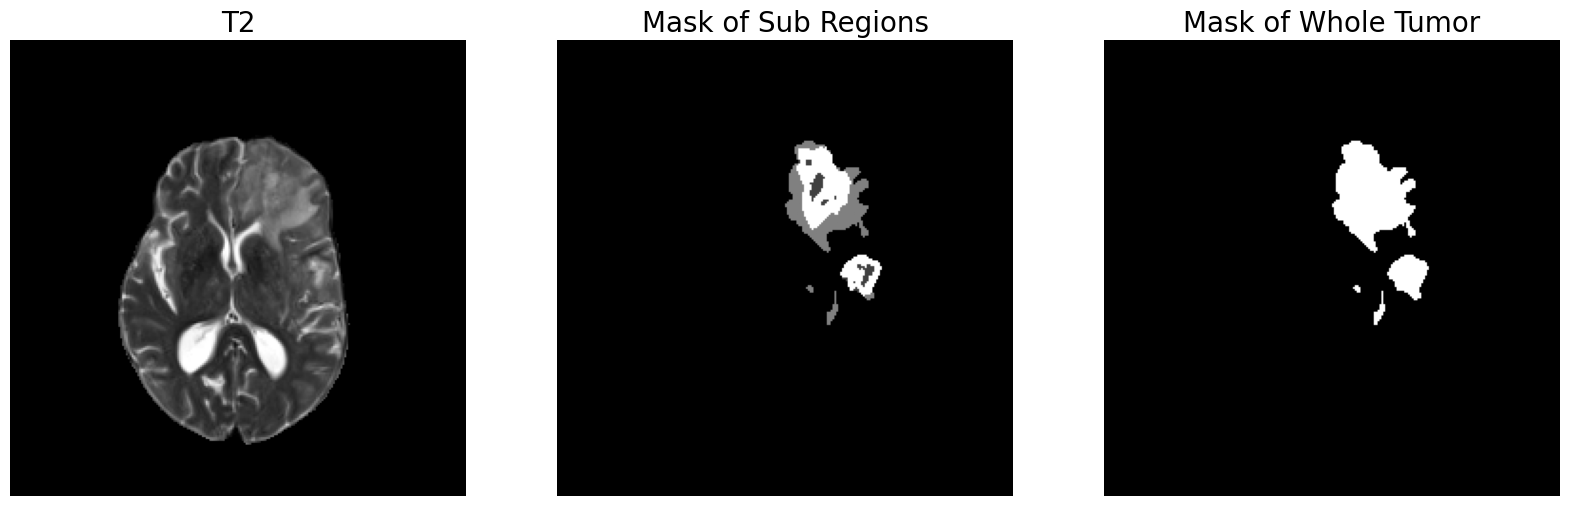

In [23]:
# Convert PyTorch tensors to NumPy arrays for plotting
img_np = img_normalized.cpu().numpy()
mask_np = mask_normalized.cpu().numpy()

# Visualize the images
plt.figure(figsize=(20, 30))

# Original T2 image
plt.subplot(1, 3, 1)
plt.imshow(img_np[:, :, 78].T, cmap='gray')  # Assuming the third dimension is the slice axis
plt.axis('off')
plt.title('T2', fontsize=20)

# Original segmentation mask
plt.subplot(1, 3, 2)
plt.imshow(seg_img[:, :, 78].T, cmap='gray')  # Directly using seg_img if it's already a NumPy array
plt.axis('off')
plt.title('Mask of Sub Regions', fontsize=20)

# Normalized mask
plt.subplot(1, 3, 3)
plt.imshow(mask_np[:, :, 78].T, cmap='gray')
plt.axis('off')
plt.title('Mask of Whole Tumor', fontsize=20)

plt.show()

### Why Normalize MRI Images?

Different MRI sequences (T1, T2, FLAIR) have vastly different intensity ranges:
- **T1**: 0-700
- **T2**: 0-300  
- **FLAIR**: 0-600

Neural networks train best when inputs are in a consistent range (typically [0,1]). Without normalization:
- Large intensity values can cause exploding gradients
- Different sequences would have different "importance" just due to scale
- Training becomes unstable and slow

We use **percentile-based normalization** (0.1% to 99.9%) rather than simple min-max to handle outliers robustly.

</br>

---
## Preprocessing for Efficient Training

Before training, we'll preprocess all our data once and store it in memory as numpy arrays. This approach:

**Why preprocess?**
- Loading NIfTI files during training is slow (I/O bottleneck)
- Normalizing volumes repeatedly wastes computation
- GPU sits idle waiting for data

**Our approach:**
1. Load each patient's volume **once**
2. Extract the middle slice (where tumors are most visible)
3. Normalize the 2D slice
4. Store all slices as numpy arrays in memory

This way, during training, we just index into pre-loaded arrays - extremely fast! The preprocessing takes 2-3 minutes but makes each epoch 10x faster.

In [24]:
def create_numpy_arrays(patient_ids,
                        modalities=['t2'],
                        slice_indices=[lambda d: d//2],
                        data_path=TRAIN_DATA_PATH):
    """
    Preprocess patient data into numpy arrays for efficient training.

    This function:
    1. Loads 3D NIfTI volumes for specified patients
    2. Extracts specific slices
    3. Normalizes each slice
    4. Returns as numpy arrays ready for training

    Args:
        patient_ids: List of patient IDs (e.g., ['BraTS20_Training_001', ...])
        modalities: List of MRI modalities to use as input channels (e.g., ['t2'])
        slice_indices: Which slices to extract as functions of depth
                      Default: [lambda d: d//2] (middle slice)
        data_path: Path to BraTS training data

    Returns:
        X: numpy array of shape (N, H, W, C) where C = len(modalities)
        Y: numpy array of shape (N, H, W, 1) containing binary masks
    """
    all_images = []
    all_masks = []

    print(f"Preprocessing {len(patient_ids)} patients with {len(modalities)} modality(ies)...")

    for patient_id in tqdm(patient_ids, desc="Loading patients"):
        # Load NIfTI volumes for this patient
        niftis_to_load = modalities + ['seg']
        pt_img_dict = read_patient_niftis(patient_id,
                                          niftis_to_load=niftis_to_load,
                                          data_path=data_path)

        # Get volume depth (same for all modalities)
        depth = pt_img_dict['seg'].shape[2]

        # Extract each requested slice
        for slice_fn in slice_indices:
            slice_idx = slice_fn(depth)

            # Normalize each modality for this slice
            channels = []
            for modality in modalities:
                # Extract 2D slice from 3D volume
                mod_volume = pt_img_dict[modality].get_fdata()
                mod_slice = mod_volume[:, :, slice_idx]

                # Also get the segmentation slice
                seg_volume = pt_img_dict['seg'].get_fdata()
                seg_slice = seg_volume[:, :, slice_idx]

                # Normalize this 2D slice
                img_normalized, mask_normalized = normalize(mod_slice, seg_slice)

                # Convert to numpy and add to channels
                img_np = img_normalized.cpu().numpy()
                channels.append(img_np)

            # Stack modalities as channels: (H, W, num_modalities)
            if len(channels) == 1:
                img_multi = np.expand_dims(channels[0], axis=-1)  # (H, W, 1)
            else:
                img_multi = np.stack(channels, axis=-1)  # (H, W, C)

            # Mask is same regardless of modality
            mask_np = mask_normalized.cpu().numpy()
            mask_np = np.expand_dims(mask_np, axis=-1)  # (H, W, 1)

            all_images.append(img_multi)
            all_masks.append(mask_np)

    X = np.array(all_images)
    Y = np.array(all_masks)

    print(f"Preprocessing complete! Shape: {X.shape}")
    print(f"Memory usage: ~{X.nbytes / 1e6:.1f} MB (images) + {Y.nbytes / 1e6:.1f} MB (masks)")

    return X, Y

In [25]:
# Now let's preprocess all our data!
# This takes 2-3 minutes but only needs to run once.
# If your kernel crashes, just rerun this cell.

print("=" * 60)
print("PREPROCESSING DATA")
print("=" * 60)

X_train, Y_train = create_numpy_arrays(train_ids)
X_val, Y_val = create_numpy_arrays(val_ids)
X_test, Y_test = create_numpy_arrays(test_ids)

print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Training:   {X_train.shape[0]} slices, {X_train.shape[-1]} channel(s)")
print(f"Validation: {X_val.shape[0]} slices, {X_val.shape[-1]} channel(s)")
print(f"Test:       {X_test.shape[0]} slices, {X_test.shape[-1]} channel(s)")
print("=" * 60)

PREPROCESSING DATA
Preprocessing 235 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 235/235 [00:07<00:00, 29.72it/s]


Preprocessing complete! Shape: (235, 240, 240, 1)
Memory usage: ~54.1 MB (images) + 108.3 MB (masks)
Preprocessing 59 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 59/59 [00:01<00:00, 33.91it/s]


Preprocessing complete! Shape: (59, 240, 240, 1)
Memory usage: ~13.6 MB (images) + 27.2 MB (masks)
Preprocessing 74 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 74/74 [00:02<00:00, 35.37it/s]

Preprocessing complete! Shape: (74, 240, 240, 1)
Memory usage: ~17.0 MB (images) + 34.1 MB (masks)

PREPROCESSING SUMMARY
Training:   235 slices, 1 channel(s)
Validation: 59 slices, 1 channel(s)
Test:       74 slices, 1 channel(s)


## Step 4: Let's take a look at the performance metrics commonly used in semantic segmentation.

The 2 common ones are
- Dice
- Jaccard/Intersection of Union (IoU)

Both Dice and Jaccard indices are bounded between 0 and 1 with 0 indicating completely inaccurate model prediction and 1 indicating completely accurate model prediction.

Performance metrics in image segmentation: https://towardsdatascience.com/metrics-to-evaluate-your-semantic-segmentation-model-6bcb99639aa2

In [40]:
smooth = 1.0  # Smoothing factor to avoid division by zero

# Dice Coefficient
def dice_coef(y_true, y_pred):
    """
    Dice coefficient for semantic segmentation.

    Dice = (2 * |X ∩ Y|) / (|X| + |Y|)
         = 2*sum(|A*B|) / (sum(A²) + sum(B²))

    Args:
        y_true: Ground truth tensor
        y_pred: Predicted tensor (after sigmoid, values in [0,1])

    Returns:
        Dice coefficient (higher is better, range [0,1])
    """

    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# Jaccard Coefficient (IoU)
def jaccard_coef(y_true, y_pred):
    """
    Jaccard coefficient for semantic segmentation (also called IoU).

    Jaccard = |X ∩ Y| / |X ∪ Y|
            = sum(|A*B|) / (sum(|A|) + sum(|B|) - sum(|A*B|))

    Args:
        y_true: Ground truth tensor
        y_pred: Predicted tensor (after sigmoid, values in [0,1])

    Returns:
        Jaccard coefficient (higher is better, range [0,1])
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    return (intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() - intersection + smooth)

## Step 5: Let's take a look at loss functions for semantic segmentation.

The default choice of loss function for segmentation and other classification tasks is Binary Cross-Entropy (BCE). Here since the metric  Dice or Jaccard Coefficient is being used to judge model performance, the loss functions that are derived from these metrics - typically in the form 1 - f(x) where f(x) is the metric in question.

Loss functions in image segmentation: https://medium.com/@junma11/loss-functions-for-medical-image-segmentation-a-taxonomy-cefa5292eec0

In [27]:
# The 2 loss functions we will look at are Dice and Jaccard loss
def dice_coef_loss(y_true, y_pred):
    """
    Dice loss for semantic segmentation.
    Minimizing this loss corresponds to maximizing the Dice coefficient.
    """
    return 1 - dice_coef(y_true, y_pred)

def jaccard_coef_loss(y_true, y_pred):
    """
    Jaccard loss for semantic segmentation.
    Minimizing this loss corresponds to maximizing the Jaccard coefficient.
    """
    return 1 - jaccard_coef(y_true, y_pred)


## Step 6: Now comes the most interesing bit of our learning!

We will now build the Unet model we are going to use for semantic segmentation of WT.

What is a UNet: https://towardsdatascience.com/understanding-semantic-segmentation-with-unet-6be4f42d4b47

Video explaining UNet: https://www.youtube.com/watch?v=azM57JuQpQI


In [28]:
class UNet(nn.Module):
    """
    U-Net architecture for semantic segmentation.

    Architecture:
    - 4 downsampling blocks (encoder) with max pooling
    - Bottleneck (center)
    - 4 upsampling blocks (decoder) with skip connections
    - Final 1x1 conv for classification

    Args:
        in_channels: Number of input channels (1 for single modality, 3 for multi-modal)
        out_channels: Number of output channels (1 for binary, 4 for multi-class)
    """
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            """Double convolution block: Conv-ReLU-BN-Conv-ReLU-BN"""
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels)
            )

        # Encoder (downsampling path)
        self.down1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.center = conv_block(512, 1024)

        # Decoder (upsampling path with skip connections)
        self.up4 = conv_block(1024 + 512, 512)
        self.up3 = conv_block(512 + 256, 256)
        self.up2 = conv_block(256 + 128, 128)
        self.up1 = conv_block(128 + 64, 64)

        # Final classification layer
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        down1 = self.down1(x)
        pool1 = self.pool1(down1)

        down2 = self.down2(pool1)
        pool2 = self.pool2(down2)

        down3 = self.down3(pool2)
        pool3 = self.pool3(down3)

        down4 = self.down4(pool3)
        pool4 = self.pool4(down4)

        # Bottleneck
        center = self.center(pool4)

        # Decoder with skip connections
        up4 = F.interpolate(center, scale_factor=2, mode='bilinear', align_corners=True)
        up4 = torch.cat([up4, down4], dim=1)
        up4 = self.up4(up4)

        up3 = F.interpolate(up4, scale_factor=2, mode='bilinear', align_corners=True)
        up3 = torch.cat([up3, down3], dim=1)
        up3 = self.up3(up3)

        up2 = F.interpolate(up3, scale_factor=2, mode='bilinear', align_corners=True)
        up2 = torch.cat([up2, down2], dim=1)
        up2 = self.up2(up2)

        up1 = F.interpolate(up2, scale_factor=2, mode='bilinear', align_corners=True)
        up1 = torch.cat([up1, down1], dim=1)
        up1 = self.up1(up1)

        # Final classification with sigmoid activation
        final = self.final(up1)
        return torch.sigmoid(final)

Instead of constant learning rate, how to use a gradually decreasing learning rate instead: https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

Lets visualize the model now!

In [30]:
!apt-get update -qq
!apt-get install -y graphviz
%pip install -q torchviz

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 128 not upgraded.


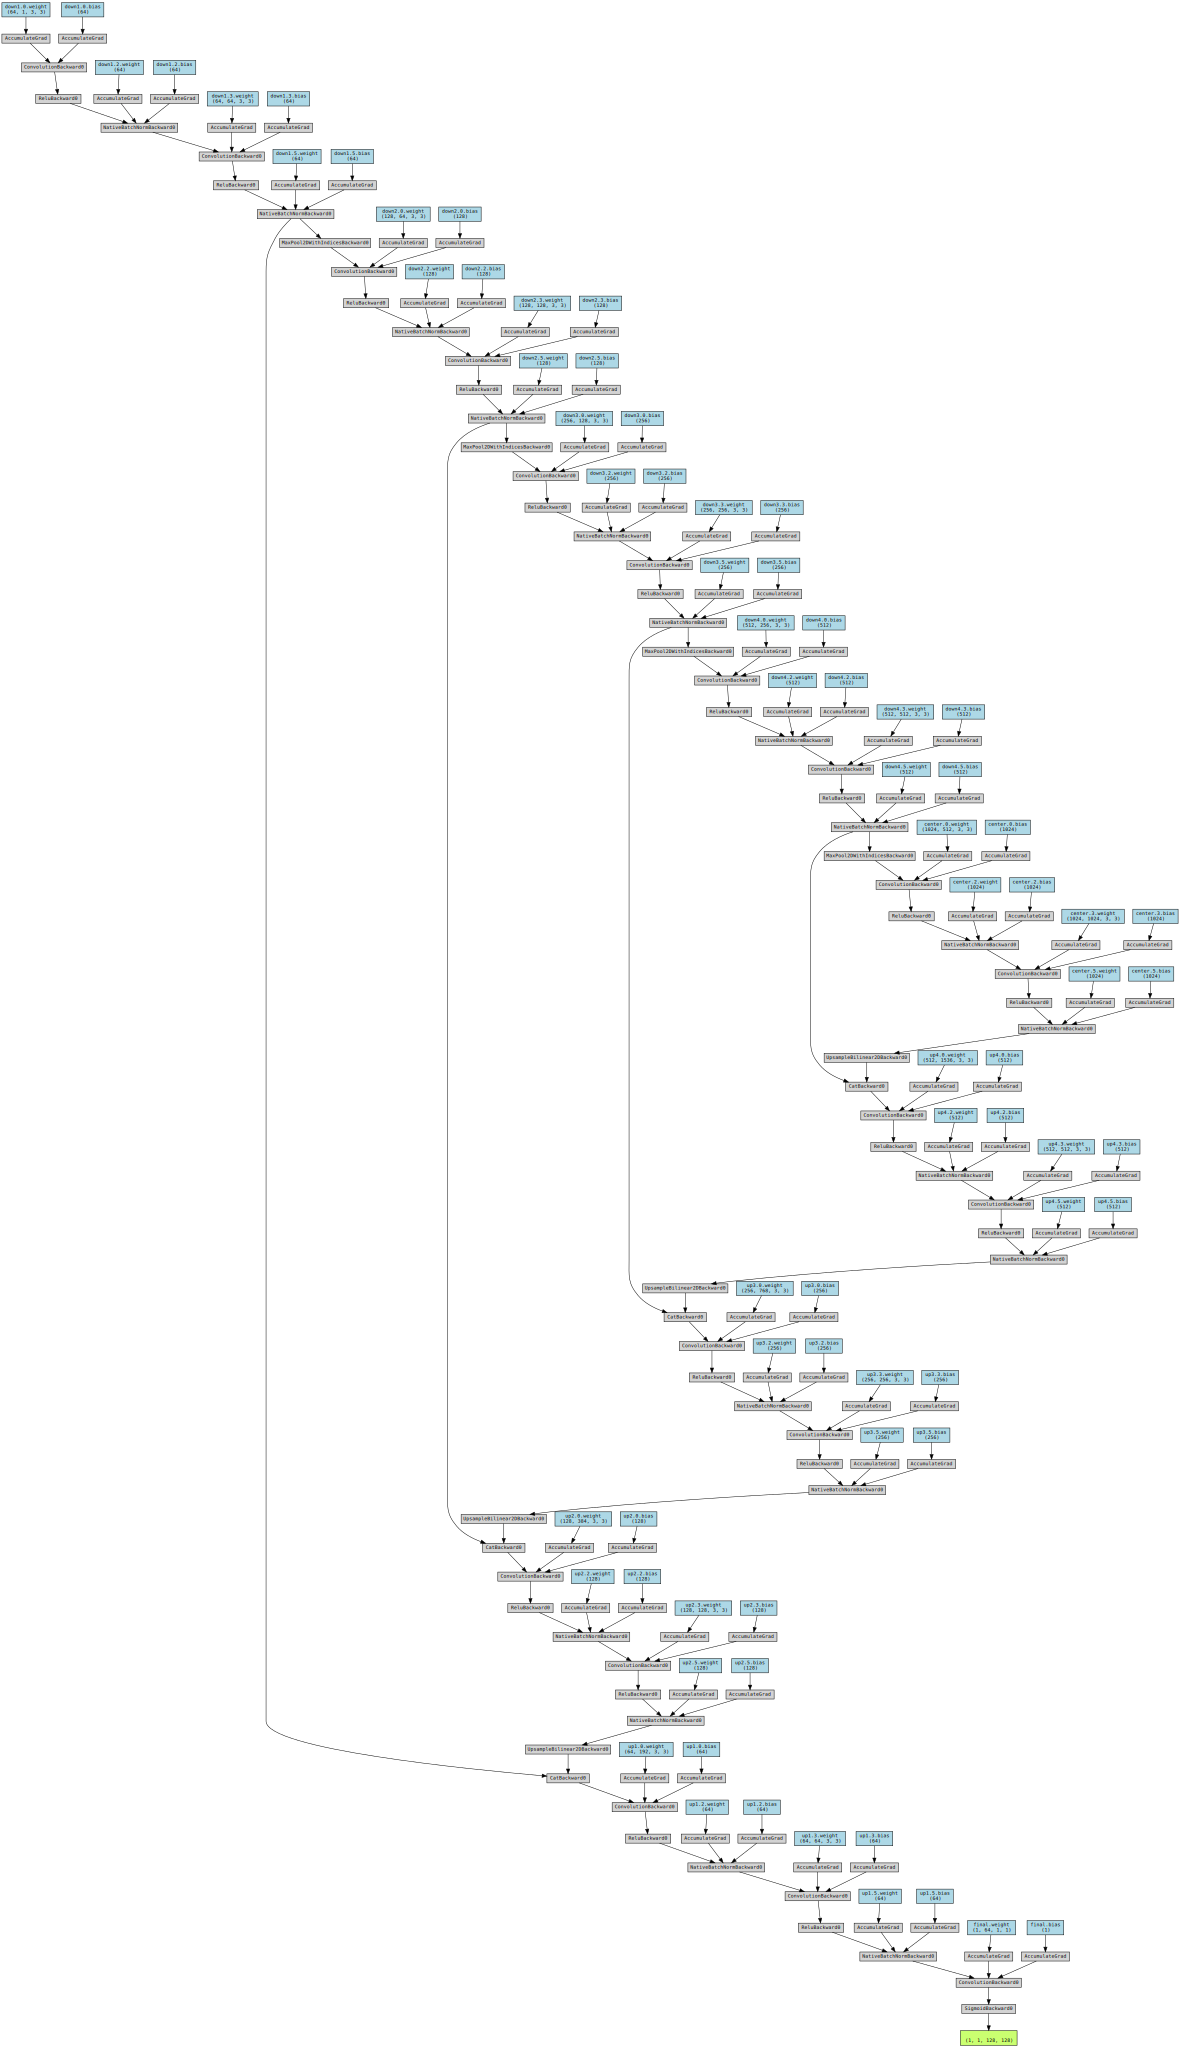

In [31]:
from torchviz import make_dot

model = UNet()

# Create a random tensor with the same size as your input
x = torch.randn(1, 1, 128, 128)  # Example input size

# Forward pass to generate the graph
y = model(x)

# Use make_dot to create a visualization
model_graph = make_dot(y, params=dict(model.named_parameters()))

# Save or display the graph
model_graph.format = 'png'
model_graph.render('unet_model')

# Display the graph in the notebook (if using Jupyter)
display(model_graph)

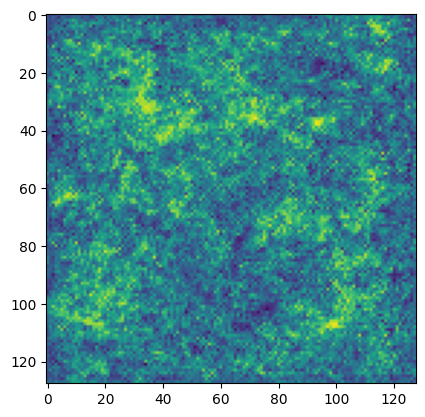

In [32]:
plt.imshow(y.detach().numpy()[0, 0, :,:])

## Step 7: Creating the DataLoader & Training

Now that we have preprocessed numpy arrays, creating a dataset is simple! PyTorch's `TensorDataset` wraps our arrays and the `DataLoader` handles batching and shuffling.

**Key parameters:**
- `batch_size`: Number of samples per batch (64 is a good balance)
- `shuffle=True`: Randomize order each epoch (prevents memorization)
- `num_workers`: Parallel data loading (0 for main thread, 2-4 for speed)

In [33]:
# Convert numpy arrays to PyTorch tensors and create datasets
# Note: We transpose from (N, H, W, C) to (N, C, H, W) - PyTorch convention
train_dataset = TensorDataset(
    torch.from_numpy(X_train).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_train).permute(0, 3, 1, 2).float()
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_val).permute(0, 3, 1, 2).float()
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_test).permute(0, 3, 1, 2).float()
)

# Create data loaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created successfully!")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created successfully!
Training batches per epoch: 4
Validation batches: 1
Test batches: 2


Now we'll use our preprocessed arrays to train the model!

In [34]:
# Let's confirm the size of the training, validation and test datasets
print(f'There are {len(train_dataset)} slices in training set')
print(f'There are {len(val_dataset)} slices in validation set')
print(f'There are {len(test_dataset)} slices in test set')
print(f'\nNote: Each "slice" is a preprocessed 2D image-mask pair')

There are 235 slices in training set
There are 59 slices in validation set
There are 74 slices in test set

Note: Each "slice" is a preprocessed 2D image-mask pair


### 7.1. Training the Baseline Model

We will now train our first model. This will serve as our **baseline**. It uses:
- **Input:** A single, middle T2 slice per patient.
- **Loss Function:** Binary Cross-Entropy (`nn.BCELoss`).
- **Output:** A binary mask for the whole tumor.

All experiments in Step 9 will be compared against this baseline's performance.

In [35]:
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.0001, use_gpu=True):
    """
    Train the U-Net model for brain tumor segmentation.

    Args:
        model: The U-Net model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        learning_rate: Learning rate for Adam optimizer
        use_gpu: Whether to use GPU if available

    Returns:
        DataFrame containing training metrics (epoch, train_loss, val_loss)
    """
    # Setup device
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Loss function: Binary Cross-Entropy (model outputs sigmoid, so use BCELoss)
    criterion = nn.BCELoss()

    # Optimizer: Adam with specified learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print("=" * 60)
    print(f"Training on: {device}")
    print(f"Epochs: {num_epochs} | Learning Rate: {learning_rate} | Batch Size: {train_loader.batch_size}")
    print("=" * 60)

    # Storage for metrics
    metrics = {'epoch': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        # ==================== TRAINING PHASE ====================
        model.train()
        running_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, masks)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ==================== VALIDATION PHASE ====================
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        # Record metrics
        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)

        # Print progress
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    print("=" * 60)
    print("Training complete!")
    print("=" * 60)

    return pd.DataFrame(metrics)

In [36]:
# Initialize the model
# in_channels=1 because we're using single modality (T2)
# For Q5 (multi-modal), you'll change this to in_channels=3 or more
model = UNet(in_channels=1, out_channels=1)

# Train the model
metrics_df = train_model(model, train_loader, val_loader, num_epochs=20, use_gpu=True)

# Display final metrics
print("\nFinal Metrics:")
print(metrics_df.tail())

Training on: cuda
Epochs: 20 | Learning Rate: 0.0001 | Batch Size: 64


Epoch  1/20 | Train Loss: 0.6509 | Val Loss: 0.6316


Epoch  2/20 | Train Loss: 0.6082 | Val Loss: 0.6087


Epoch  3/20 | Train Loss: 0.5784 | Val Loss: 0.5848


Epoch  4/20 | Train Loss: 0.5615 | Val Loss: 0.5939


...

Epoch 16/20 | Train Loss: 0.4918 | Val Loss: 0.4434


Epoch 17/20 | Train Loss: 0.4883 | Val Loss: 0.4648


Epoch 18/20 | Train Loss: 0.4815 | Val Loss: 0.4785


Epoch 19/20 | Train Loss: 0.4803 | Val Loss: 0.4561


Epoch 20/20 | Train Loss: 0.4762 | Val Loss: 0.4382
Training complete!

Final Metrics:
    epoch  train_loss  val_loss
15     16    0.491844  0.443394
16     17    0.488276  0.464820
17     18    0.481459  0.478532
18     19    0.480328  0.456065
19     20    0.476238  0.438203


### 7.2. Saving the Baseline Model (Optional but Recommended)

Training takes time! To avoid retraining the model every time you work on this notebook, you can save its learned parameters (weights). I know how frustrating it is when the session disconnects/times out.

In [37]:
# Define a path to save the model
MODEL_PATH = './baseline_unet_t2.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), MODEL_PATH)

print(f"Baseline model saved to {MODEL_PATH}")

# You can later load it back like this:
# model_to_load = UNet(in_channels=1, out_channels=1)
# model_to_load.load_state_dict(torch.load(MODEL_PATH))
# model_to_load.to(device) # Don't forget to move it to the GPU!
# print("Baseline model reloaded successfully!")

Baseline model saved to ./baseline_unet_t2.pth


## Step 8: Your turn

### 8.1. Learning curves

Learning curves are a widely used diagnostic tool in machine learning for algorithms that learn from a training dataset incrementally. The model can be evaluated on the training dataset and on a hold out validation dataset after each update during training and plots of the measured performance can created to show learning curves.

Importance of learning curves: https://towardsdatascience.com/learning-curve-to-identify-overfitting-underfitting-problems-133177f38df5

Below, figure out how to visualize a learning curve using the metrics that you've created above.

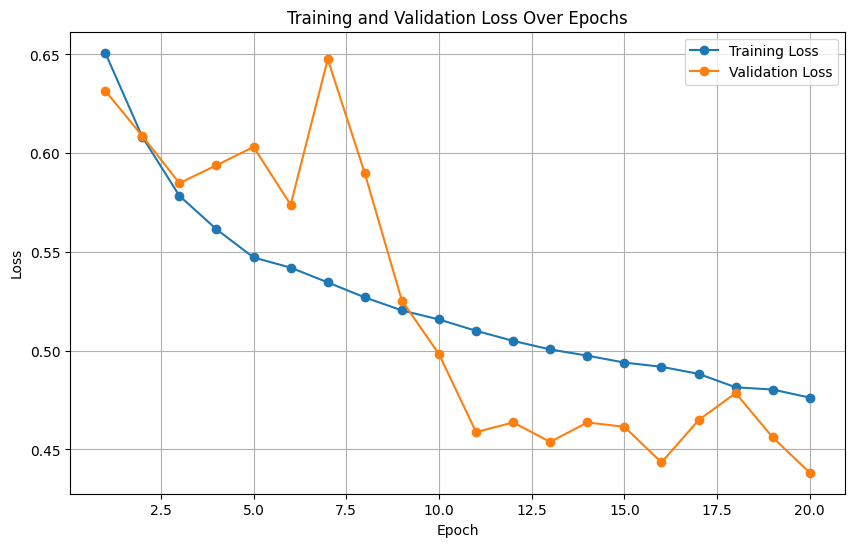

In [38]:
# ============================================================
# TODO: Visualize Learning Curves
# ============================================================

# Create a plot showing training and validation loss over epochs
plt.figure(figsize=(10, 6))

# TODO: Plot training loss
plt.plot(metrics_df['epoch'], metrics_df['train_loss'], label='Training Loss', marker='o')

# TODO: Plot validation loss
plt.plot(metrics_df['epoch'], metrics_df['val_loss'], label='Validation Loss', marker='o')

# TODO: Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')

plt.legend()
plt.grid(True)
plt.show()

# Questions to consider after plotting:
# - Is the model overfitting (val_loss >> train_loss)?
# - Has the model converged or does it need more epochs?
# - At which epoch does the best validation performance occur?

## Is the model overfitting (val_loss >> train_loss)?

No, overfitting would typically show the training loss continuing to decrease while the validation loss starts increasing and diverging upward. Here, both losses generally decrease over time, and after about epoch 10 the validation loss is actually lower than the training loss for most of the run. That suggests the model is learning useful patterns and still generalizing reasonably well rather than memorizing the training set.

## Has the model converged or does it need more epochs?

The model appears to be mostly converged. The training loss keeps decreasing gradually, but the validation loss improves much more slowly after roughly epochs 11–16 and only fluctuates slightly after that. So additional epochs might give small gains, but the curve suggests diminishing returns rather than major further improvement. This is consistent with a model approaching convergence.

## At which epoch does the best validation performance occur?

The best validation performance occurs at epoch 20, because that is where the validation loss reaches its minimum value on the plot, approximately 0.44.

Understanding difference between batch and epoch in deep learning: https://machinelearningmastery.com/difference-between-a-batch-and-an-epoch/

Are there ways to automate hyper-parameter tuning: https://neptune.ai/blog/hyperparameter-tuning-in-python-complete-guide

### 8.2 Visualizing the outputs
Figure out a way to visualize the outputs of the model. Take a look at the ground truth masks next to the outputs of the model for a few images. Try to look at a slice in the volume that matters. Would you say the model is doing a good or bad job at creating predictions right now?

*Hint*: Remember that `matplotlib` and `numpy` work on the CPU. Before you can visualize a tensor, you must first move it from the GPU back to the CPU using `.cpu()` (e.g., `tensor.cpu().numpy()`).

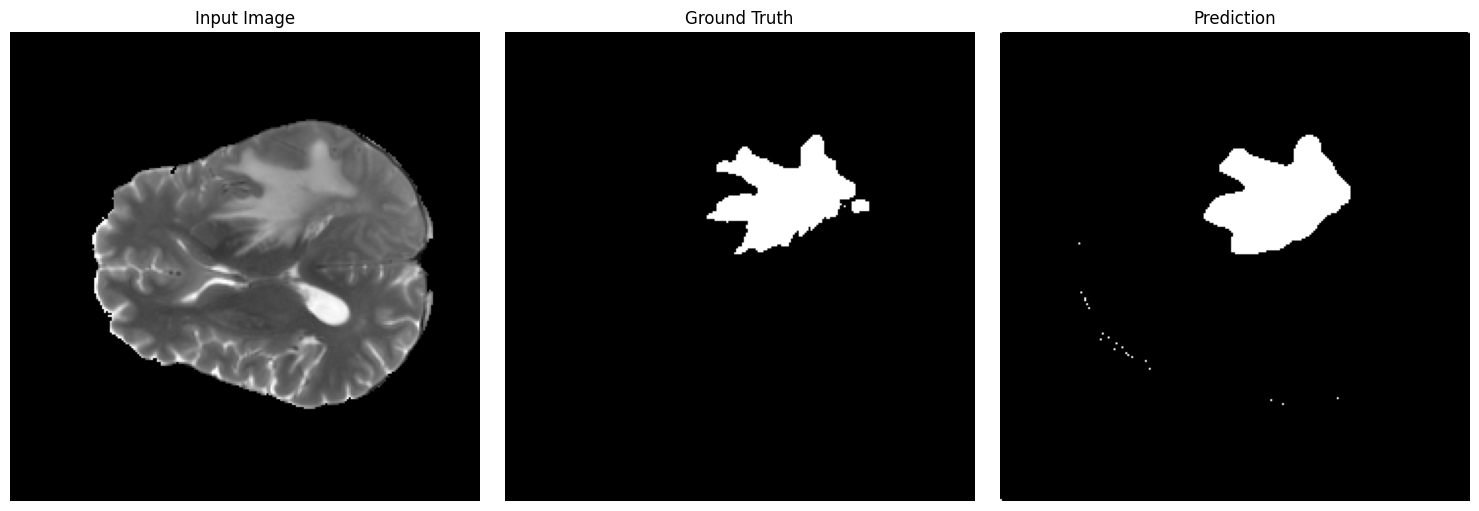

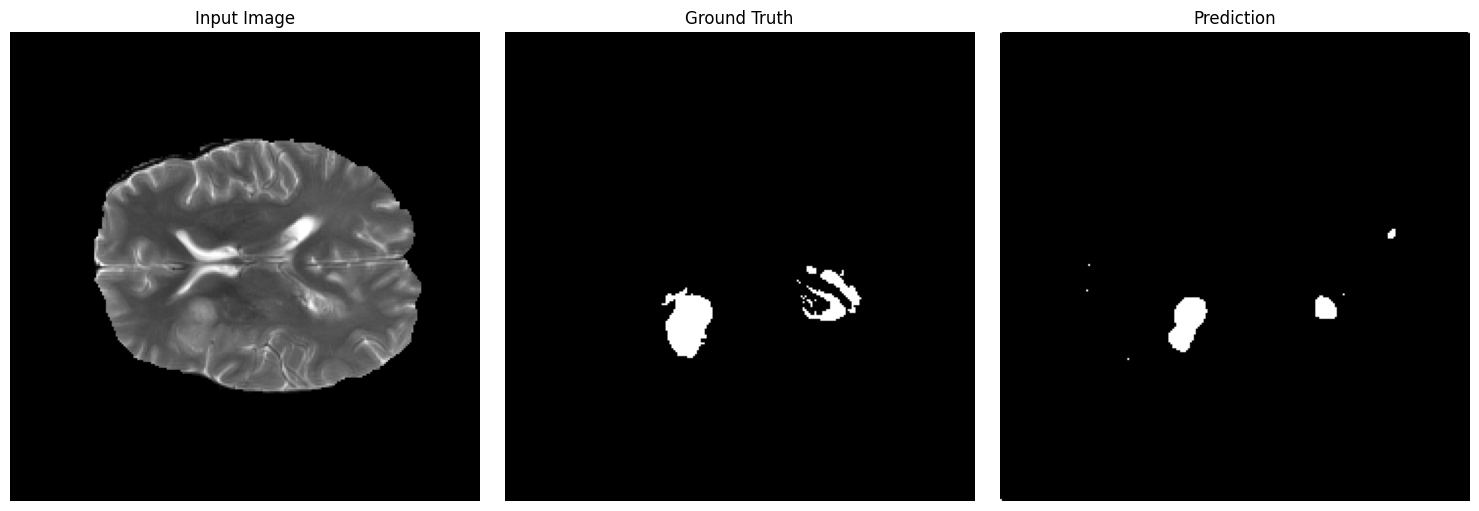

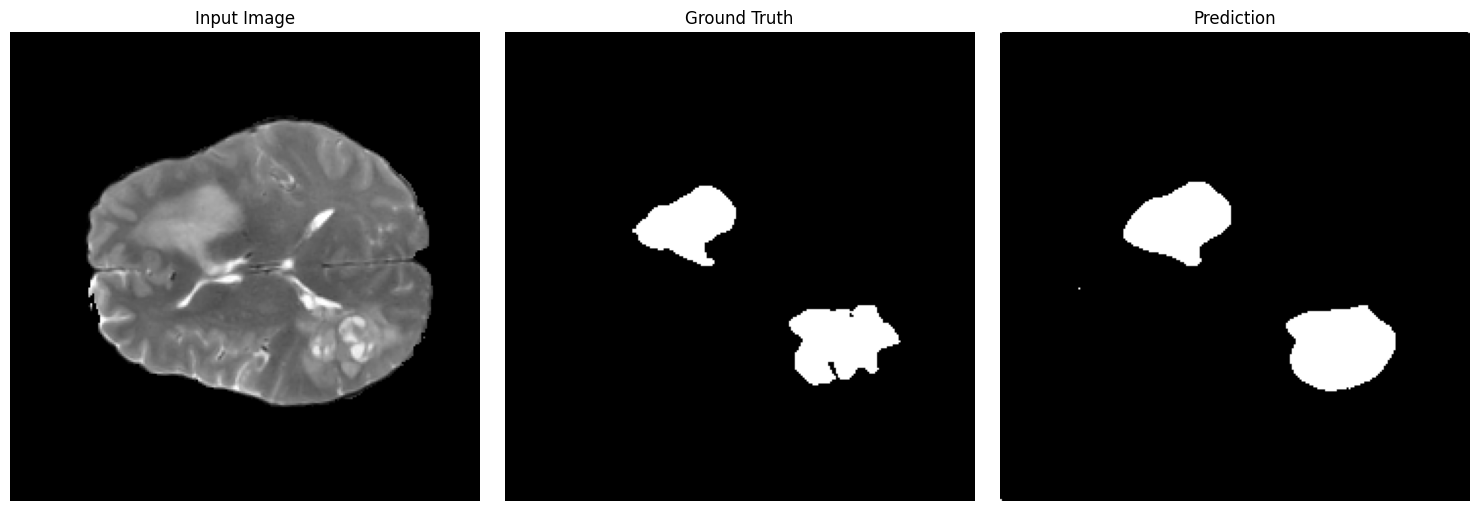

In [39]:
# ============================================================
# TODO: Visualize Model Predictions vs Ground Truth
# ============================================================

# Set model to evaluation mode
model.eval()
device = next(model.parameters()).device

# Get one batch from test set
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)

        # TODO: Get model predictions
        outputs = model(images)

        # Visualize first 3 samples
        num_samples = min(3, images.shape[0])

        for i in range(num_samples):
            plt.figure(figsize=(15, 5))

            # Input Image
            plt.subplot(1, 3, 1)
            # TODO: Extract the i-th image from the batch (hint: index and squeeze channel dim)
            input_img = images[i].squeeze().cpu().numpy()
            plt.imshow(input_img, cmap='gray')
            plt.title('Input Image')
            plt.axis('off')

            # Ground Truth Mask
            plt.subplot(1, 3, 2)
            # TODO: Extract the i-th mask from the batch
            true_mask = masks[i].squeeze().cpu().numpy()
            plt.imshow(true_mask, cmap='gray')
            plt.title('Ground Truth')
            plt.axis('off')

            # Predicted Mask
            plt.subplot(1, 3, 3)
            # TODO: Extract prediction, threshold at 0.5, convert to numpy
            pred_mask = (outputs[i].squeeze() > 0.5).float().cpu().numpy()
            plt.imshow(pred_mask, cmap='gray')
            plt.title('Prediction')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        break  # Only process one batch

# Analysis questions:
# - Does the model capture tumor boundaries accurately?
# - Are there false positives (predicting tumor where there's none)?
# - Are there false negatives (missing actual tumor regions)?
# - Which cases does the model handle well vs poorly?

## Does the model capture tumor boundaries accurately?

Partially. The model usually finds the main tumor regions, but the predicted masks are smoother and less detailed than the ground-truth masks. In several cases, the overall location is correct, but fine boundary details and small irregular structures are not captured precisely.

## Are there false positives (predicting tumor where there's none)?

Yes, there are several false positives. In the first and second examples, the prediction includes small scattered white dots and streaks in background regions where the ground truth has no tumor. In the second example, there is also an extra small predicted region that does not clearly match the ground truth. In segmentation terms, a false positive means the model predicts tumor for pixels that are actually background.

## Are there false negatives (missing actual tumor regions)?

Yes, there are false negatives. The model tends to miss smaller or more detailed tumor parts. In the first example, it misses the small separate ground-truth region on the right. In the second example, it does not fully recover the more complex right-side tumor structure. In segmentation terms, a false negative means tumor pixels in the ground truth were missed by the prediction.

## Which cases does the model handle well vs poorly?

The model handles larger, compact tumor regions better. It performs best when the tumor shape is relatively solid and prominent, as in the third example, where both major regions are detected reasonably well. It performs worse on small, fragmented, or highly irregular tumor regions, where it either smooths them out, misses parts of them, or adds small spurious predictions.

## Step 9: Extensions and Experiments

Now that you have a working brain tumor segmentation model, it's time to experiment! The questions below will help you understand what factors affect model performance.

**Important**: For each question, **copy the relevant cells from above and modify them** - don't change your original working code.

---

### Question 1: Jaccard Loss Function [2 points]

**Task**: Retrain the model using **Jaccard loss** instead of BCE loss, and track the **Jaccard coefficient** as a metric.

**Hints**:
- Look at the loss functions defined in Step 5
- You'll need to modify the `train_model` function's `criterion` variable
- Consider adding a metrics tracking loop to compute Jaccard score each epoch

**Report**:
- Final Jaccard scores on training and validation sets
- Does Jaccard loss lead to better Jaccard scores than BCE loss?



In [41]:
# ============================================================
# Question 1: Train with Jaccard Loss
# ============================================================

# TODO: Modify the train_model function to use Jaccard loss

def train_model_q1(model, train_loader, val_loader, num_epochs=10, learning_rate=0.0001, use_gpu=True):
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model.to(device)

    # TODO: Replace with appropriate loss function from Step 5
    criterion = jaccard_coef_loss

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    metrics = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_jaccard': [], 'val_jaccard': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_jaccard = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # TODO: Compute Jaccard coefficient for this batch
            with torch.no_grad():
                batch_jaccard = jaccard_coef(masks, outputs)
                running_jaccard += batch_jaccard.item()

        train_loss = running_loss / len(train_loader)
        train_jaccard = running_jaccard / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_jaccard = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                # TODO: Compute validation loss and Jaccard
                loss = criterion(masks, outputs)
                jaccard = jaccard_coef(masks, outputs)

                val_loss += loss.item()
                val_jaccard += jaccard.item()

        val_loss /= len(val_loader)
        val_jaccard /= len(val_loader)

        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        metrics['train_jaccard'].append(train_jaccard)
        metrics['val_jaccard'].append(val_jaccard)

        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Jaccard: {val_jaccard:.4f}")

    return pd.DataFrame(metrics)

# TODO: Train the model
model_q1 = UNet(in_channels=1, out_channels=1)
metrics_q1 = train_model_q1(model_q1, train_loader, val_loader, num_epochs=20, use_gpu=True)

print("\nFinal Question 1 Metrics:")
print(metrics_q1.tail())

print("\nFinal Jaccard scores:")
print(f"Train Jaccard: {metrics_q1['train_jaccard'].iloc[-1]:.4f}")
print(f"Val Jaccard:   {metrics_q1['val_jaccard'].iloc[-1]:.4f}")

Epoch  1/20 | Train Loss: 0.9495 | Val Loss: 0.9688 | Val Jaccard: 0.0312


Epoch  2/20 | Train Loss: 0.9344 | Val Loss: 0.9676 | Val Jaccard: 0.0324


Epoch  3/20 | Train Loss: 0.9289 | Val Loss: 0.9649 | Val Jaccard: 0.0351


Epoch  4/20 | Train Loss: 0.9243 | Val Loss: 0.9603 | Val Jaccard: 0.0397


Epoch  5/20 | Train Loss: 0.9192 | Val Loss: 0.9538 | Val Jaccard: 0.0462


...

Epoch 16/20 | Train Loss: 0.8988 | Val Loss: 0.8857 | Val Jaccard: 0.1143


Epoch 17/20 | Train Loss: 0.8956 | Val Loss: 0.8877 | Val Jaccard: 0.1123


Epoch 18/20 | Train Loss: 0.8942 | Val Loss: 0.8852 | Val Jaccard: 0.1148


Epoch 19/20 | Train Loss: 0.8952 | Val Loss: 0.8739 | Val Jaccard: 0.1261


Epoch 20/20 | Train Loss: 0.8925 | Val Loss: 0.8710 | Val Jaccard: 0.1290

Final Question 1 Metrics:
    epoch  train_loss  val_loss  train_jaccard  val_jaccard
15     16    0.898797  0.885739       0.101203     0.114261
16     17    0.895595  0.887658       0.104405     0.112342
17     18    0.894237  0.885237       0.105763     0.114763
18     19    0.895178  0.873892       0.104822     0.126108
19     20    0.892460  0.871045       0.107540     0.128955

Final Jaccard scores:
Train Jaccard: 0.1075
Val Jaccard:   0.1290


Jaccard loss leads to better Jaccard scores than BCE loss.

### Question 2: Tracking Multiple Metrics [2 points]

**Task**: Keep using BCE loss, but track **both Dice and Jaccard coefficients** as additional metrics during training.

**Hints**:
- The metric functions are already defined - you just need to call them
- Add new columns to the metrics dictionary: 'train_dice', 'val_dice', 'train_jaccard', 'val_jaccard'
- Compute these during the training and validation loops (inside `torch.no_grad()` for validation)

**Report**:
- Create 3 plots:
  - Plot 1: Training loss vs Validation loss
  - Plot 2: Training Dice vs Validation Dice
  - Plot 3: Training Jaccard vs Validation Jaccard
- Which metric stabilizes faster?
- How closely do Dice and Jaccard track each other?


Epoch  1/20 | Loss: 0.6790/0.6518 | Dice: 0.0737/0.0601 | Jaccard: 0.0383/0.0310


Epoch  2/20 | Loss: 0.6385/0.6352 | Dice: 0.0896/0.0603 | Jaccard: 0.0469/0.0311


Epoch  3/20 | Loss: 0.6064/0.6206 | Dice: 0.0993/0.0609 | Jaccard: 0.0523/0.0314


Epoch  4/20 | Loss: 0.5867/0.6141 | Dice: 0.1035/0.0627 | Jaccard: 0.0546/0.0324


Epoch  5/20 | Loss: 0.5669/0.6172 | Dice: 0.1087/0.0653 | Jaccard: 0.0575/0.0338


...

Epoch 16/20 | Loss: 0.4934/0.4893 | Dice: 0.1257/0.1265 | Jaccard: 0.0671/0.0675


Epoch 17/20 | Loss: 0.4904/0.5790 | Dice: 0.1269/0.1326 | Jaccard: 0.0678/0.0710


Epoch 18/20 | Loss: 0.4868/0.5052 | Dice: 0.1270/0.1280 | Jaccard: 0.0678/0.0684


Epoch 19/20 | Loss: 0.4834/0.4852 | Dice: 0.1274/0.1319 | Jaccard: 0.0680/0.0706


Epoch 20/20 | Loss: 0.4816/0.5536 | Dice: 0.1281/0.1304 | Jaccard: 0.0684/0.0697

Final Question 2 Metrics:
    epoch  train_loss  val_loss  train_dice  val_dice  train_jaccard  \
15     16    0.493446  0.489257    0.125696  0.126478       0.067078   
16     17    0.490448  0.578960    0.126892  0.132603       0.067791   
17     18    0.486773  0.505184    0.127029  0.127981       0.067827   
18     19    0.483379  0.485238    0.127411  0.131924       0.068046   
19     20    0.481609  0.553630    0.128077  0.130397       0.068441   

    val_jaccard  
15     0.067509  
16     0.071010  
17     0.068366  
18     0.070620  
19     0.069746  

Final BCE Jaccard scores:
Train Jaccard: 0.0684
Val Jaccard:   0.0697


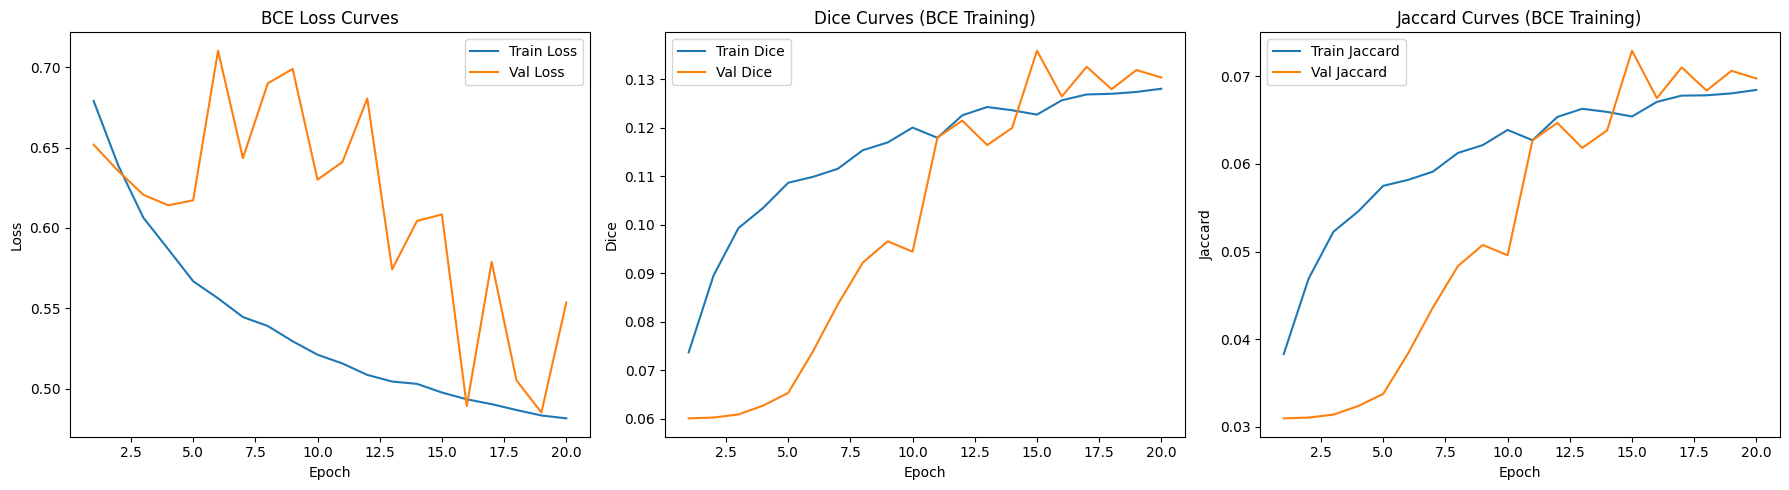

In [43]:
# ============================================================
# Question 2: Track Dice and Jaccard with BCE Loss
# ============================================================

def train_model_q2(model, train_loader, val_loader, num_epochs=10, learning_rate=0.0001, use_gpu=True):
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.BCELoss()  # Keep BCE loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # TODO: Add Dice and Jaccard to metrics dictionary
    metrics = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'train_dice': [],
        'val_dice': [],
        'train_jaccard': [],
        'val_jaccard': [],
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_dice = 0.0
        running_jaccard = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # TODO: Compute and accumulate Dice and Jaccard scores
            with torch.no_grad():
                batch_dice = dice_coef(masks, outputs)
                batch_jaccard = jaccard_coef(masks, outputs)
                running_dice += batch_dice.item()
                running_jaccard += batch_jaccard.item()

        # TODO: Compute averages for all metrics
        train_loss = running_loss / len(train_loader)
        train_dice = running_dice / len(train_loader)
        train_jaccard = running_jaccard / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_jaccard = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                # TODO: Compute all three validation metrics
                loss = criterion(outputs, masks)
                dice = dice_coef(masks, outputs)
                jaccard = jaccard_coef(masks, outputs)

                val_loss += loss.item()
                val_dice += dice.item()
                val_jaccard += jaccard.item()

        # TODO: Average validation metrics
        val_loss /= len(val_loader)
        val_dice /= len(val_loader)
        val_jaccard /= len(val_loader)

        # TODO: Store all metrics
        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        metrics['train_dice'].append(train_dice)
        metrics['val_dice'].append(val_dice)
        metrics['train_jaccard'].append(train_jaccard)
        metrics['val_jaccard'].append(val_jaccard)

        print(
            f"Epoch {epoch+1:2d}/{num_epochs} | "
            f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
            f"Dice: {train_dice:.4f}/{val_dice:.4f} | "
            f"Jaccard: {train_jaccard:.4f}/{val_jaccard:.4f}"
        )

    return pd.DataFrame(metrics)

# TODO: Create 3 subplots to visualize loss, Dice, and Jaccard curves
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# ... plotting code ...
model_q2 = UNet(in_channels=1, out_channels=1)
metrics_q2 = train_model_q2(
    model_q2,
    train_loader,
    val_loader,
    num_epochs=20,
    learning_rate=0.0001,
    use_gpu=True
)

print("\nFinal Question 2 Metrics:")
print(metrics_q2.tail())

print("\nFinal BCE Jaccard scores:")
print(f"Train Jaccard: {metrics_q2['train_jaccard'].iloc[-1]:.4f}")
print(f"Val Jaccard:   {metrics_q2['val_jaccard'].iloc[-1]:.4f}")


# Plot loss, Dice, and Jaccard curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(metrics_q2['epoch'], metrics_q2['train_loss'], label='Train Loss')
axes[0].plot(metrics_q2['epoch'], metrics_q2['val_loss'], label='Val Loss')
axes[0].set_title('BCE Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(metrics_q2['epoch'], metrics_q2['train_dice'], label='Train Dice')
axes[1].plot(metrics_q2['epoch'], metrics_q2['val_dice'], label='Val Dice')
axes[1].set_title('Dice Curves (BCE Training)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()

axes[2].plot(metrics_q2['epoch'], metrics_q2['train_jaccard'], label='Train Jaccard')
axes[2].plot(metrics_q2['epoch'], metrics_q2['val_jaccard'], label='Val Jaccard')
axes[2].set_title('Jaccard Curves (BCE Training)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Jaccard')
axes[2].legend()

plt.tight_layout()
plt.show()

Dice and Jaccard stabilize at almost the same rate in this experiment. Both validation metrics remain low in the early epochs, increase substantially around the middle of training, and begin to plateau with some fluctuations after about epoch 11. Dice appears slightly smoother, but neither metric clearly converges earlier than the other. They also track each other extremely closely because they are mathematically related: Dice is a monotonic transformation of Jaccard. This is confirmed by the final validation results, where Dice = 0.1304 and Jaccard = 0.0697, which are consistent with their theoretical relationship.

---

### Question 3: Different MRI Modality [2 points]

**Task**: Train a model using **a different MRI modality** (T1, T1CE, or FLAIR) instead of T2.

**Hints**:
- The `create_numpy_arrays()` function has a `modalities` parameter
- You'll need to rerun preprocessing with your chosen modality
- Train a new model and compare to the T2 baseline

**Report**:
- Which modality did you choose and what was its validation Dice score?
- Compare to T2 baseline - which performs better?
- Visualize a few predictions - what differences do you notice in how it segments tumors?


Preprocessing 235 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 235/235 [00:08<00:00, 28.01it/s]


Preprocessing complete! Shape: (235, 240, 240, 1)
Memory usage: ~54.1 MB (images) + 108.3 MB (masks)
Preprocessing 59 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 59/59 [00:02<00:00, 29.10it/s]


Preprocessing complete! Shape: (59, 240, 240, 1)
Memory usage: ~13.6 MB (images) + 27.2 MB (masks)
Preprocessing 74 patients with 1 modality(ies)...


...

Epoch 16/20 | Loss: 0.4866/0.6374 | Dice: 0.1263/0.1451 | Jaccard: 0.0675/0.0782


Epoch 17/20 | Loss: 0.4795/0.4759 | Dice: 0.1295/0.1407 | Jaccard: 0.0692/0.0757


Epoch 18/20 | Loss: 0.4726/0.4942 | Dice: 0.1319/0.1523 | Jaccard: 0.0707/0.0824


Epoch 19/20 | Loss: 0.4703/0.4292 | Dice: 0.1301/0.1482 | Jaccard: 0.0696/0.0800


Epoch 20/20 | Loss: 0.4647/0.4276 | Dice: 0.1321/0.1457 | Jaccard: 0.0707/0.0786

Final Question 3 Metrics:
    epoch  train_loss  val_loss  train_dice  val_dice  train_jaccard  \
15     16    0.486640  0.637361    0.126311  0.145094       0.067459   
16     17    0.479540  0.475930    0.129482  0.140730       0.069229   
17     18    0.472605  0.494182    0.131889  0.152254       0.070668   
18     19    0.470285  0.429153    0.130089  0.148216       0.069599   
19     20    0.464661  0.427638    0.132128  0.145711       0.070748   

    val_jaccard  
15     0.078222  
16     0.075691  
17     0.082400  
18     0.080040  
19     0.078581  

Final FLAIR validation Dice: 0.1457
T2 baseline validation Dice: 0.1304
Better modality: FLAIR


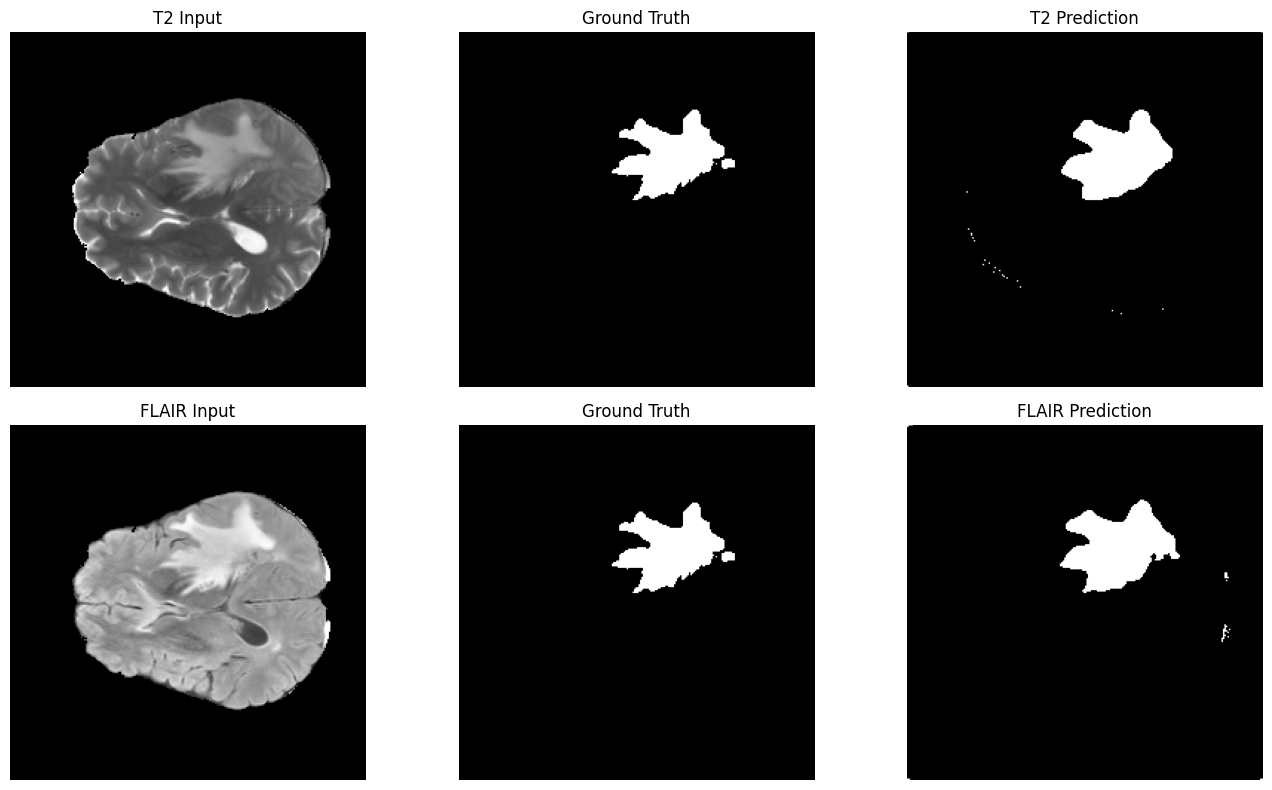

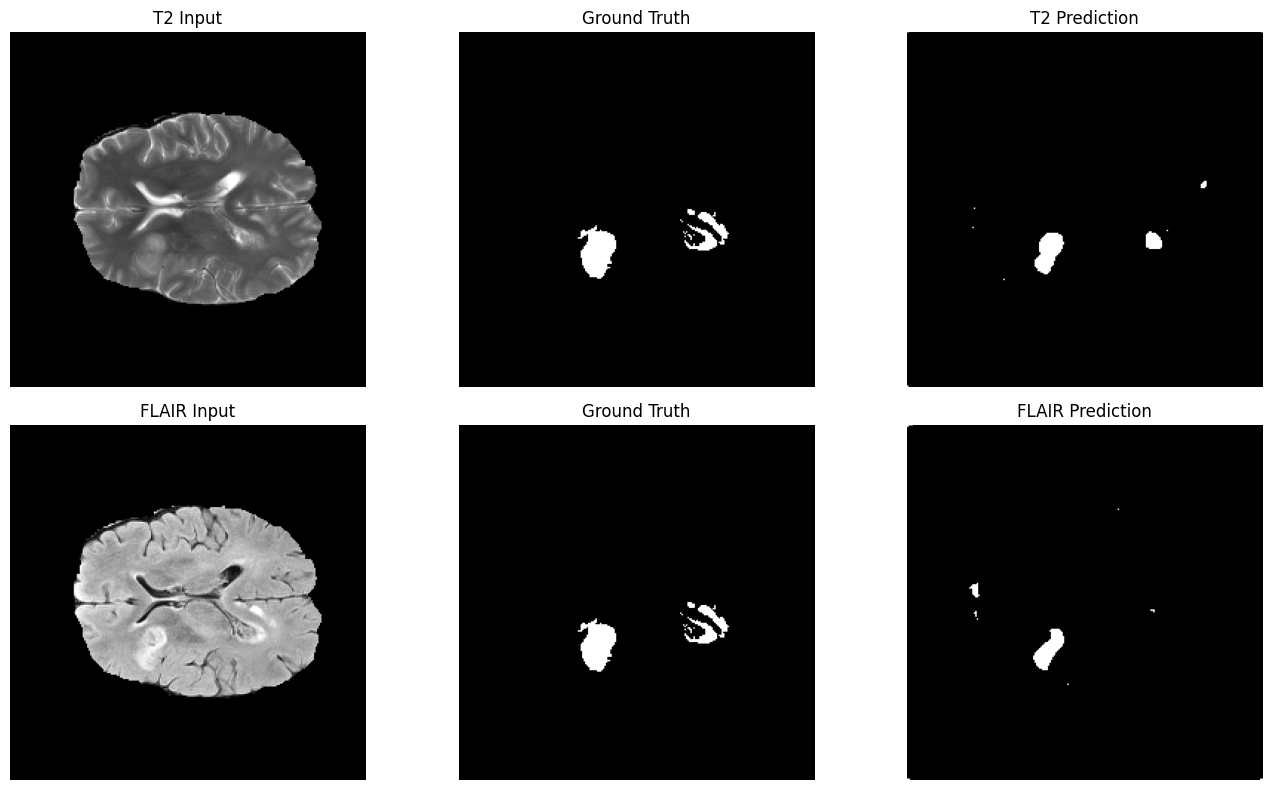

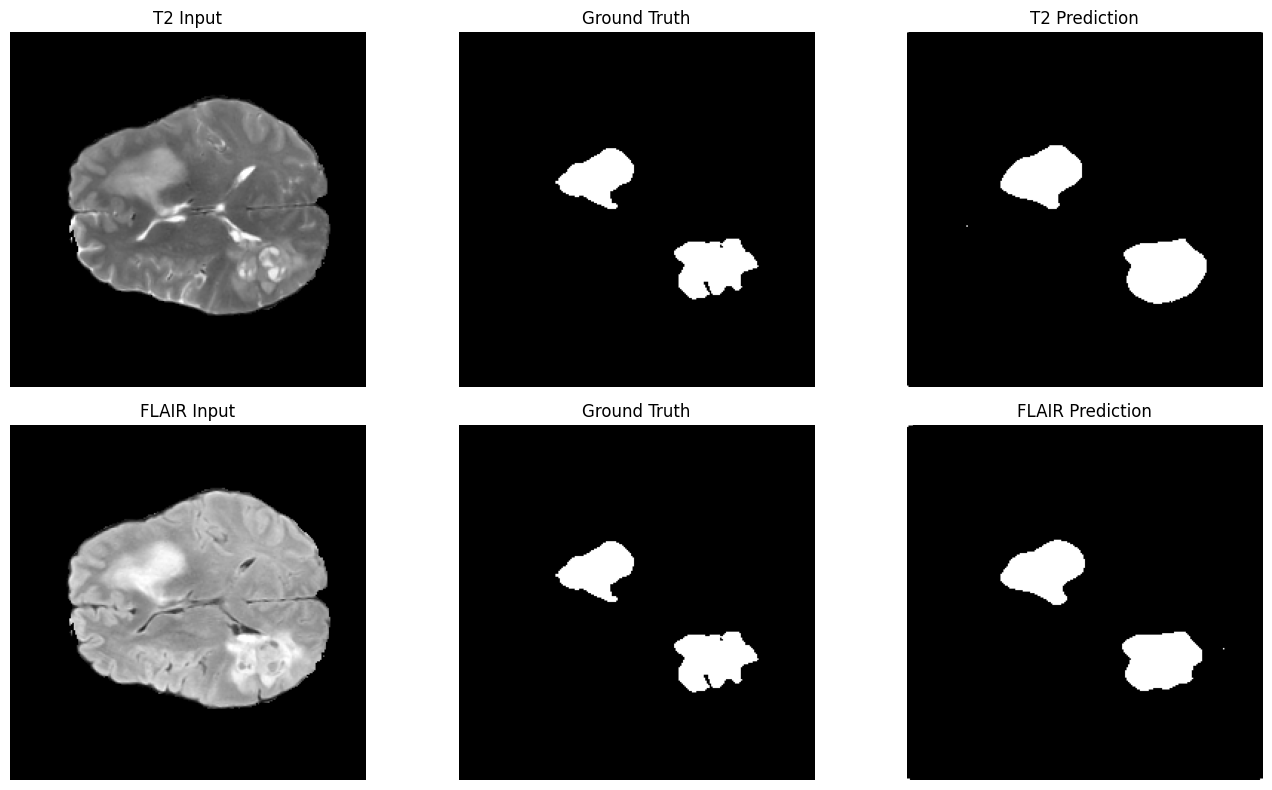

In [44]:
# ============================================================
# Question 3: Try a Different Modality
# ============================================================

MODALITY_Q3 = 'flair'   # choose one of: 't1', 't1ce', 'flair'

# Preprocess with the chosen modality
X_train_q3, Y_train_q3 = create_numpy_arrays(train_ids, modalities=[MODALITY_Q3])
X_val_q3, Y_val_q3 = create_numpy_arrays(val_ids, modalities=[MODALITY_Q3])
X_test_q3, Y_test_q3 = create_numpy_arrays(test_ids, modalities=[MODALITY_Q3])

# Create datasets
train_dataset_q3 = TensorDataset(
    torch.from_numpy(X_train_q3).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_train_q3).permute(0, 3, 1, 2).float()
)

val_dataset_q3 = TensorDataset(
    torch.from_numpy(X_val_q3).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_val_q3).permute(0, 3, 1, 2).float()
)

test_dataset_q3 = TensorDataset(
    torch.from_numpy(X_test_q3).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_test_q3).permute(0, 3, 1, 2).float()
)

# Create data loaders
BATCH_SIZE_Q3 = 64

train_loader_q3 = DataLoader(
    train_dataset_q3,
    batch_size=BATCH_SIZE_Q3,
    shuffle=True,
    num_workers=2
)

val_loader_q3 = DataLoader(
    val_dataset_q3,
    batch_size=BATCH_SIZE_Q3,
    shuffle=False,
    num_workers=2
)

test_loader_q3 = DataLoader(
    test_dataset_q3,
    batch_size=BATCH_SIZE_Q3,
    shuffle=False,
    num_workers=0
)

print(f"Question 3 modality: {MODALITY_Q3}")
print(f"Training set shape:   {X_train_q3.shape}")
print(f"Validation set shape: {X_val_q3.shape}")
print(f"Test set shape:       {X_test_q3.shape}")

# Train model
# Use train_model_q2 so we get Dice and Jaccard metrics in addition to loss
model_q3 = UNet(in_channels=1, out_channels=1)

metrics_q3 = train_model_q2(
    model_q3,
    train_loader_q3,
    val_loader_q3,
    num_epochs=20,
    learning_rate=0.0001,
    use_gpu=True
)

print("\nFinal Question 3 Metrics:")
print(metrics_q3.tail())

print(f"\nFinal {MODALITY_Q3.upper()} validation Dice: {metrics_q3['val_dice'].iloc[-1]:.4f}")

if 'metrics_q2' in globals():
    baseline_val_dice = metrics_q2['val_dice'].iloc[-1]
    better_modality = MODALITY_Q3.upper() if metrics_q3['val_dice'].iloc[-1] > baseline_val_dice else 'T2'
    print(f"T2 baseline validation Dice: {baseline_val_dice:.4f}")
    print(f"Better modality: {better_modality}")
else:
    print("Run Question 2 first if you want an apples-to-apples T2 Dice comparison.")

# Visualize predictions: T2 baseline vs chosen modality
if 'model' in globals():
    model.eval()
    model_q3.eval()

    baseline_device = next(model.parameters()).device
    q3_device = next(model_q3.parameters()).device

    with torch.no_grad():
        baseline_images, baseline_masks = next(iter(test_loader))
        q3_images, q3_masks = next(iter(test_loader_q3))

        baseline_outputs = model(baseline_images.to(baseline_device))
        q3_outputs = model_q3(q3_images.to(q3_device))

    num_samples = min(3, baseline_images.shape[0], q3_images.shape[0])

    for i in range(num_samples):
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))

        # Row 1: T2 baseline
        axes[0, 0].imshow(baseline_images[i].squeeze().cpu().numpy(), cmap='gray')
        axes[0, 0].set_title('T2 Input')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(baseline_masks[i].squeeze().cpu().numpy(), cmap='gray')
        axes[0, 1].set_title('Ground Truth')
        axes[0, 1].axis('off')

        baseline_pred = (baseline_outputs[i].squeeze() > 0.5).float().cpu().numpy()
        axes[0, 2].imshow(baseline_pred, cmap='gray')
        axes[0, 2].set_title('T2 Prediction')
        axes[0, 2].axis('off')

        # Row 2: Question 3 modality
        axes[1, 0].imshow(q3_images[i].squeeze().cpu().numpy(), cmap='gray')
        axes[1, 0].set_title(f'{MODALITY_Q3.upper()} Input')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(q3_masks[i].squeeze().cpu().numpy(), cmap='gray')
        axes[1, 1].set_title('Ground Truth')
        axes[1, 1].axis('off')

        q3_pred = (q3_outputs[i].squeeze() > 0.5).float().cpu().numpy()
        axes[1, 2].imshow(q3_pred, cmap='gray')
        axes[1, 2].set_title(f'{MODALITY_Q3.upper()} Prediction')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Baseline T2 model variable `model` not found. Re-run the baseline training cell if you want visual comparison plots.")

I chose FLAIR as the alternate modality. Its final validation Dice score was 0.1457. Compared with the T2 baseline validation Dice of 0.1304, FLAIR performed better. From the prediction visualizations, both models usually captured the main tumor mass, but FLAIR often produced slightly cleaner masks with fewer scattered false positives on some slices. However, FLAIR was not better in every case: in harder examples with multiple disconnected tumor regions, both models missed components, and sometimes T2 recovered more of the structure. Overall, FLAIR gave the better average validation result, while both methods still struggled with small secondary regions and occasional false positives.

---

### Question 4: Using Multiple Slices [3 points]

**Task**: Instead of using only the middle slice, use **three slices** per patient to increase training data.

**Hints**:
- Look at the `slice_indices` parameter in `create_numpy_arrays()`
- Currently it's `[lambda d: d//2]` (one slice at 50% depth)
- Think about how to specify multiple slice positions (e.g., 25%, 50%, 75%)
- After preprocessing with more slices, your dataset will be 3x larger

**Report**:
- Does having 3x more training data improve validation Dice score?
- Compare learning curves between single-slice and multi-slice training

**Note**: This approach treats each slice independently. For capturing spatial context between slices, you'd need 3D convolutions or channel stacking (see Q5).



Preprocessing 235 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 235/235 [00:10<00:00, 23.15it/s]


Preprocessing complete! Shape: (705, 240, 240, 1)
Memory usage: ~162.4 MB (images) + 324.9 MB (masks)
Preprocessing 59 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 59/59 [00:02<00:00, 23.63it/s]


Preprocessing complete! Shape: (177, 240, 240, 1)
Memory usage: ~40.8 MB (images) + 81.6 MB (masks)
Preprocessing 74 patients with 1 modality(ies)...


...

Epoch 16/20 | Loss: 0.5888/0.6141 | Dice: 0.0599/0.0625 | Jaccard: 0.0311/0.0322


Epoch 17/20 | Loss: 0.5740/0.5447 | Dice: 0.0545/0.0612 | Jaccard: 0.0280/0.0316


Epoch 18/20 | Loss: 0.6277/0.5136 | Dice: 0.0554/0.0600 | Jaccard: 0.0285/0.0309


Epoch 19/20 | Loss: 0.6183/0.5225 | Dice: 0.0499/0.0607 | Jaccard: 0.0257/0.0313


Epoch 20/20 | Loss: 0.5461/0.5952 | Dice: 0.0559/0.0679 | Jaccard: 0.0288/0.0351

Final Question 4 Metrics:
    epoch  train_loss  val_loss  train_dice  val_dice  train_jaccard  \
15     16    0.588783  0.614085    0.059869  0.062475       0.031131   
16     17    0.574017  0.544653    0.054491  0.061199       0.028029   
17     18    0.627688  0.513623    0.055394  0.059978       0.028510   
18     19    0.618264  0.522542    0.049883  0.060728       0.025651   
19     20    0.546136  0.595173    0.055911  0.067891       0.028769   

    val_jaccard  
15     0.032250  
16     0.031570  
17     0.030920  
18     0.031319  
19     0.035145  

Q4 final validation Dice: 0.0679
Q2 single-slice final validation Dice: 0.1304


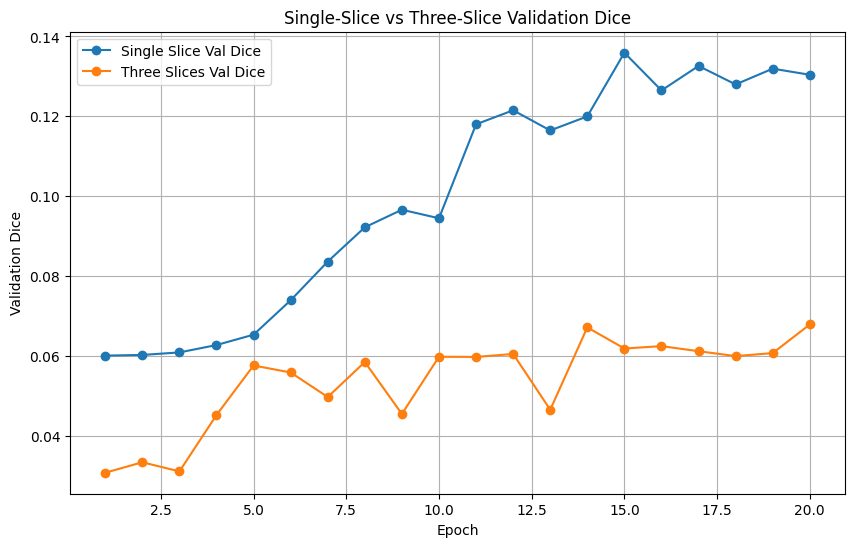

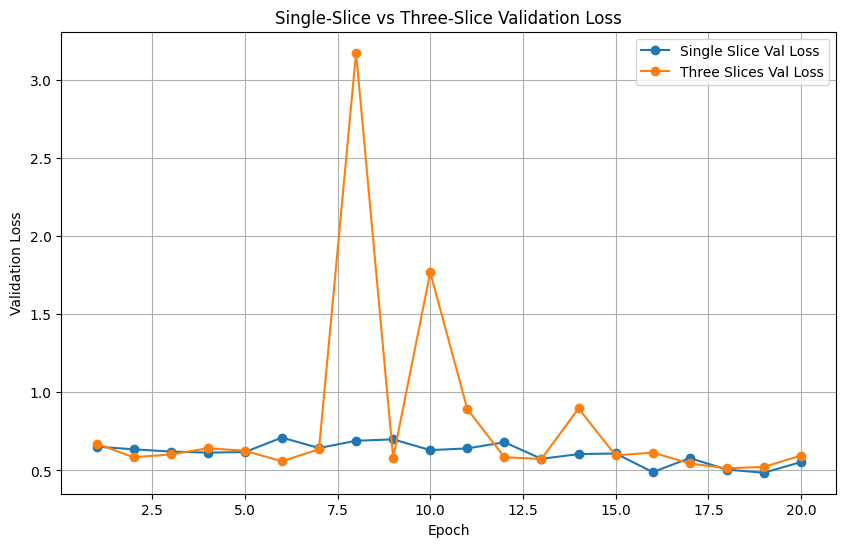

In [45]:
# ============================================================
# Question 4: Train with Multiple Slices
# ============================================================

# Use three slice positions per patient: 25%, 50%, 75% depth
SLICE_INDICES_Q4 = [
    lambda d: d // 4,
    lambda d: d // 2,
    lambda d: (3 * d) // 4,
]

# Preprocess with 3 slices per patient
X_train_q4, Y_train_q4 = create_numpy_arrays(
    train_ids,
    modalities=['t2'],
    slice_indices=SLICE_INDICES_Q4
)

X_val_q4, Y_val_q4 = create_numpy_arrays(
    val_ids,
    modalities=['t2'],
    slice_indices=SLICE_INDICES_Q4
)

X_test_q4, Y_test_q4 = create_numpy_arrays(
    test_ids,
    modalities=['t2'],
    slice_indices=SLICE_INDICES_Q4
)

# Create datasets
train_dataset_q4 = TensorDataset(
    torch.from_numpy(X_train_q4).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_train_q4).permute(0, 3, 1, 2).float()
)

val_dataset_q4 = TensorDataset(
    torch.from_numpy(X_val_q4).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_val_q4).permute(0, 3, 1, 2).float()
)

test_dataset_q4 = TensorDataset(
    torch.from_numpy(X_test_q4).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_test_q4).permute(0, 3, 1, 2).float()
)

# Create data loaders
BATCH_SIZE_Q4 = 64

train_loader_q4 = DataLoader(
    train_dataset_q4,
    batch_size=BATCH_SIZE_Q4,
    shuffle=True,
    num_workers=2
)

val_loader_q4 = DataLoader(
    val_dataset_q4,
    batch_size=BATCH_SIZE_Q4,
    shuffle=False,
    num_workers=2
)

test_loader_q4 = DataLoader(
    test_dataset_q4,
    batch_size=BATCH_SIZE_Q4,
    shuffle=False,
    num_workers=0
)

print(f"Q4 training slices:   {len(train_dataset_q4)}")
print(f"Q4 validation slices: {len(val_dataset_q4)}")
print(f"Q4 test slices:       {len(test_dataset_q4)}")

# Train model
# Still in_channels=1 because each slice is treated as an independent 2D sample,
# not as 3 input channels.
model_q4 = UNet(in_channels=1, out_channels=1)

# Question 2 trainer so we can compare validation Dice directly
metrics_q4 = train_model_q2(
    model_q4,
    train_loader_q4,
    val_loader_q4,
    num_epochs=20,
    learning_rate=0.0001,
    use_gpu=True
)

print("\nFinal Question 4 Metrics:")
print(metrics_q4.tail())

print(f"\nQ4 final validation Dice: {metrics_q4['val_dice'].iloc[-1]:.4f}")
print(f"Q2 single-slice final validation Dice: {metrics_q2['val_dice'].iloc[-1]:.4f}")

# Compare learning curves
plt.figure(figsize=(10, 6))
plt.plot(metrics_q2['epoch'], metrics_q2['val_dice'], label='Single Slice Val Dice', marker='o')
plt.plot(metrics_q4['epoch'], metrics_q4['val_dice'], label='Three Slices Val Dice', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation Dice')
plt.title('Single-Slice vs Three-Slice Validation Dice')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(metrics_q2['epoch'], metrics_q2['val_loss'], label='Single Slice Val Loss', marker='o')
plt.plot(metrics_q4['epoch'], metrics_q4['val_loss'], label='Three Slices Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Single-Slice vs Three-Slice Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**No, having 3× more training data did not improve the validation Dice score in this experiment.** Dice is an overlap metric for segmentation, so higher values indicate better agreement between the predicted mask and the ground-truth mask. In the single-slice setting, the final validation Dice was **0.1304**, while in the three-slice setting it was only **0.0679**. That means the multi-slice version performed substantially worse, even though it used more training examples.

**Comparing the learning curves:**

The **single-slice model** showed a much stronger and more consistent improvement over time. Its validation Dice increased fairly steadily from about **0.06** at the beginning to about **0.13** by the end, with only minor fluctuations. The **three-slice model** improved only slightly, starting near **0.03** and ending around **0.068**, and it mostly plateaued in the **0.05–0.07** range. The validation loss curve for the three-slice setup was also much noisier, including large spikes around **epochs 8 and 10**, whereas the single-slice validation loss stayed much more stable overall. So the single-slice training curve looks smoother, more stable, and more effective.

In this setup, adding more slices increased the amount of data, but not the quality of the supervision. The extra slices likely introduced more variation and may have included many less informative views, which made optimization harder instead of helping the model generalize. So the main conclusion is that **more data did not help here; the single central slice was more useful than using three slices at 25%, 50%, and 75% depth.**


---

### Question 5: Multi-Modal Input [4 points]

**Task**: Use **multiple MRI modalities** as different input channels (like RGB images have 3 color channels).

**Hints**:
- Use the `modalities` parameter in `create_numpy_arrays()` to load multiple sequences
- Your preprocessed arrays will have shape (N, H, W, C) where C = number of modalities
- The UNet class has an `in_channels` parameter - does it need to change?
- Think about what value `in_channels` should be when you have multiple modalities

**Requirements**:
- Try at least **3 different combinations** of modalities
- Examples: ['t1', 't2'], ['t2', 'flair'], ['t1', 't1ce', 'flair'], ['t1', 't2', 'flair', 't1ce']

**Report**:
- Table showing each combination and its validation Dice score
- Which combination works best?
- Does using more modalities always help? Why or why not?
- Visualize predictions from your best combination vs single modality

**Reasoning**: Each modality shows different tissue properties. T1 shows anatomy, T2 shows edema/fluid, T1CE shows blood-brain barrier breakdown, FLAIR suppresses CSF. Combining them provides complementary information.


Question 5 | Combination: T2 + FLAIR
Modalities: ['t2', 'flair']
Preprocessing 235 patients with 2 modality(ies)...


Loading patients: 100%|██████████| 235/235 [00:12<00:00, 18.63it/s]


Preprocessing complete! Shape: (235, 240, 240, 2)
Memory usage: ~108.3 MB (images) + 108.3 MB (masks)
Preprocessing 59 patients with 2 modality(ies)...


Loading patients: 100%|██████████| 59/59 [00:02<00:00, 21.89it/s]


Preprocessing complete! Shape: (59, 240, 240, 2)
Memory usage: ~27.2 MB (images) + 27.2 MB (masks)
Preprocessing 74 patients with 2 modality(ies)...


...

Epoch 18/20 | Loss: 0.5233/0.5193 | Dice: 0.1241/0.1396 | Jaccard: 0.0662/0.0750


Epoch 19/20 | Loss: 0.5199/0.5163 | Dice: 0.1257/0.1332 | Jaccard: 0.0671/0.0713


Epoch 20/20 | Loss: 0.5151/0.5149 | Dice: 0.1269/0.1366 | Jaccard: 0.0679/0.0733

Question 5 comparison table:


,Combination,Num_Channels,Val_Dice,Val_Jaccard
0,T1 + T1CE + FLAIR,3,0.147870,0.079838
1,T1 + T2 + FLAIR + T1CE,4,0.136588,0.073301
2,T2 + FLAIR,2,0.133759,0.071673



Best Q5 combination: T1 + T1CE + FLAIR
Best Q5 validation Dice: 0.1479
T2 single-modality baseline Dice: 0.1304
Dice improvement vs baseline: +0.0175


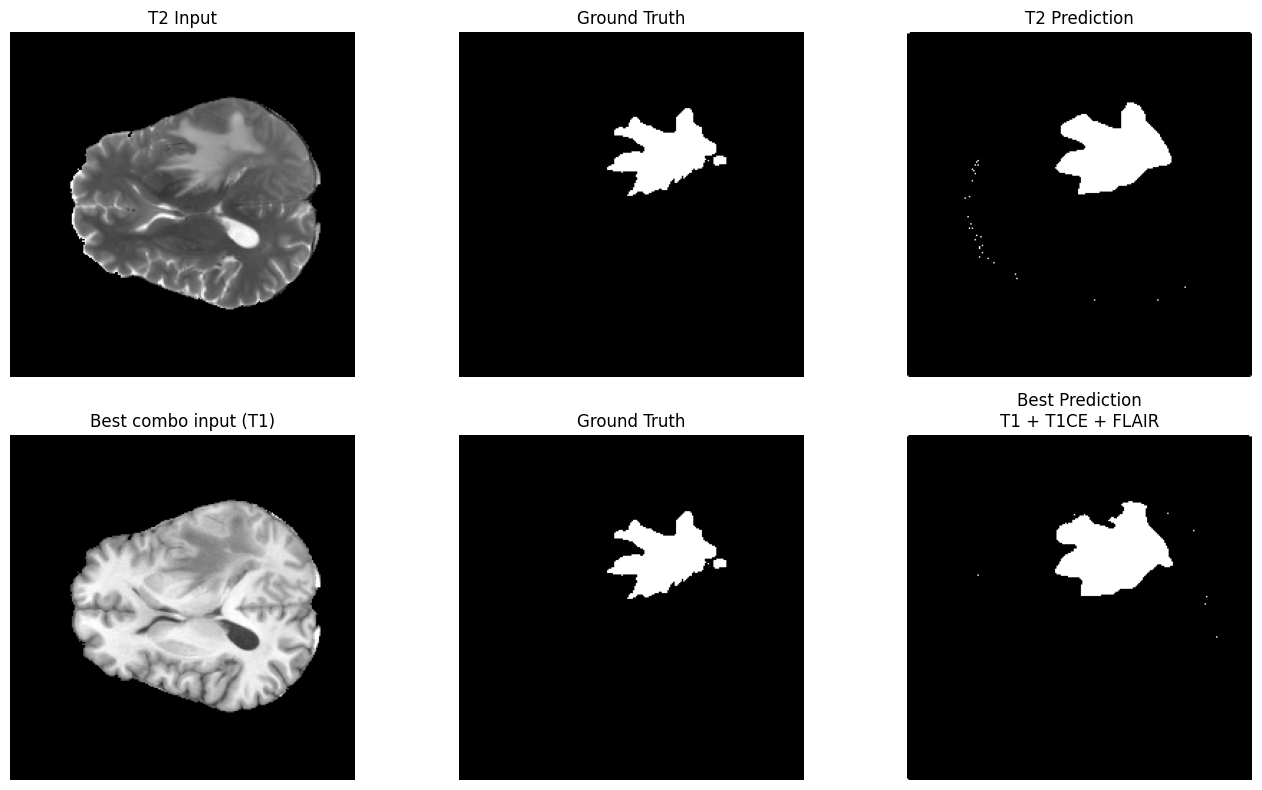

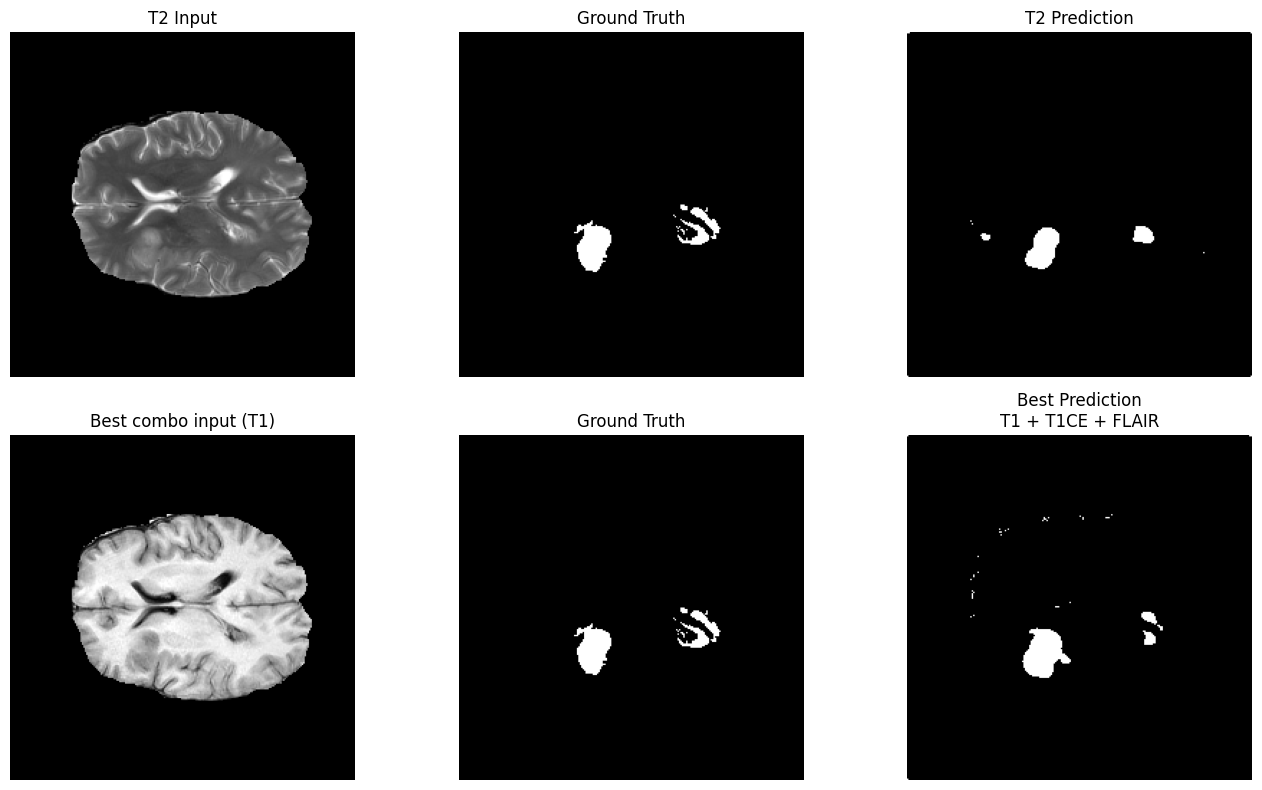

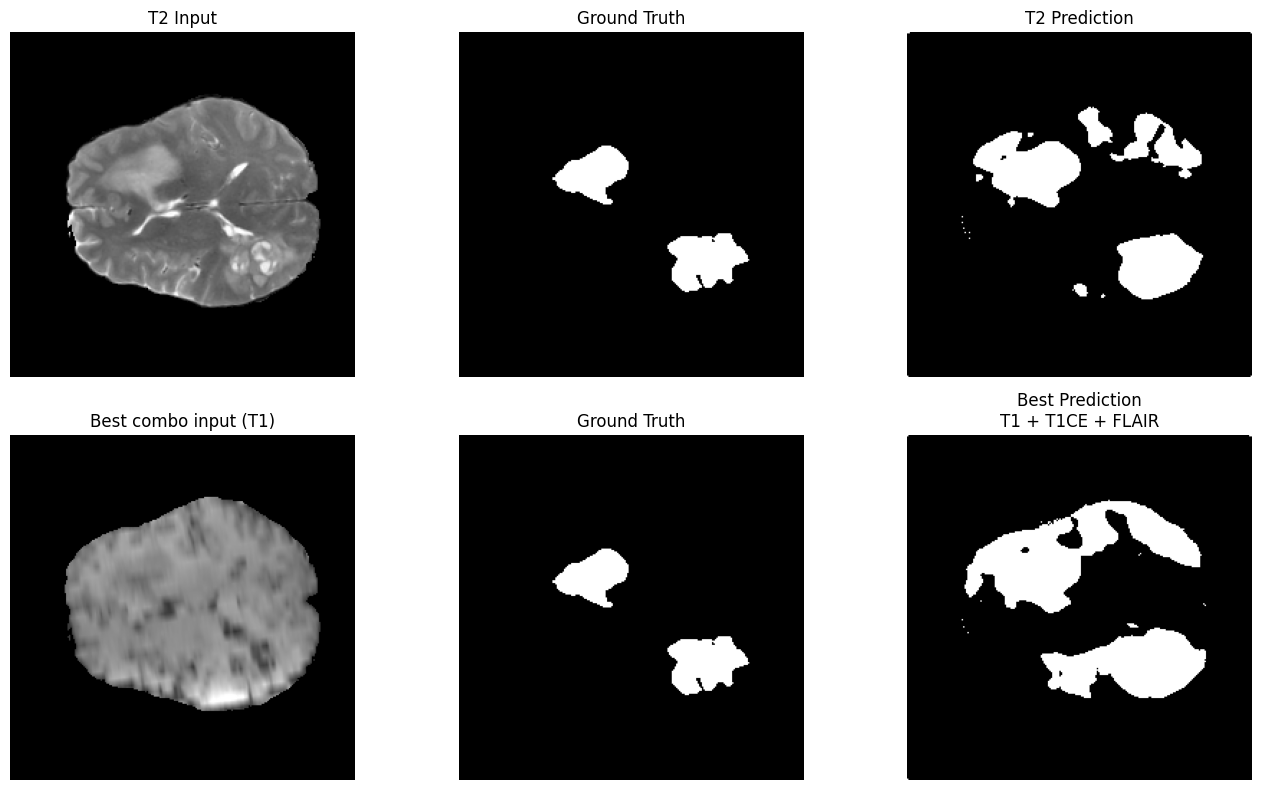

In [46]:
# ============================================================
# Question 5: Multi-Modal Input
# ============================================================

MODALITY_COMBINATIONS_Q5 = {
    'T2 + FLAIR': ['t2', 'flair'],
    'T1 + T1CE + FLAIR': ['t1', 't1ce', 'flair'],
    'T1 + T2 + FLAIR + T1CE': ['t1', 't2', 'flair', 't1ce'],
}

Q5_BATCH_SIZE = 64
Q5_EPOCHS = 20
q5_runs = {}

for combination_name, modalities in MODALITY_COMBINATIONS_Q5.items():
    print('\n' + '=' * 80)
    print(f'Question 5 | Combination: {combination_name}')
    print(f'Modalities: {modalities}')
    print('=' * 80)

    # Preprocess data for this modality combination
    X_train_q5, Y_train_q5 = create_numpy_arrays(train_ids, modalities=modalities)
    X_val_q5, Y_val_q5 = create_numpy_arrays(val_ids, modalities=modalities)
    X_test_q5, Y_test_q5 = create_numpy_arrays(test_ids, modalities=modalities)

    # Create datasets
    train_dataset_q5 = TensorDataset(
        torch.from_numpy(X_train_q5).permute(0, 3, 1, 2).float(),
        torch.from_numpy(Y_train_q5).permute(0, 3, 1, 2).float()
    )
    val_dataset_q5 = TensorDataset(
        torch.from_numpy(X_val_q5).permute(0, 3, 1, 2).float(),
        torch.from_numpy(Y_val_q5).permute(0, 3, 1, 2).float()
    )
    test_dataset_q5 = TensorDataset(
        torch.from_numpy(X_test_q5).permute(0, 3, 1, 2).float(),
        torch.from_numpy(Y_test_q5).permute(0, 3, 1, 2).float()
    )

    # Create data loaders
    train_loader_q5 = DataLoader(
        train_dataset_q5,
        batch_size=Q5_BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    val_loader_q5 = DataLoader(
        val_dataset_q5,
        batch_size=Q5_BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    test_loader_q5 = DataLoader(
        test_dataset_q5,
        batch_size=Q5_BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    print(f"Training set shape:   {X_train_q5.shape}")
    print(f"Validation set shape: {X_val_q5.shape}")
    print(f"Test set shape:       {X_test_q5.shape}")

    # in_channels must match the number of modalities
    model_q5 = UNet(in_channels=len(modalities), out_channels=1)

    # Train with the Question 2 trainer so Dice/Jaccard are tracked
    metrics_q5 = train_model_q2(
        model_q5,
        train_loader_q5,
        val_loader_q5,
        num_epochs=Q5_EPOCHS,
        learning_rate=0.0001,
        use_gpu=True
    )

    q5_runs[combination_name] = {
        'modalities': modalities,
        'model': model_q5,
        'metrics': metrics_q5,
        'test_loader': test_loader_q5,
    }

# Create comparison table
results_q5 = pd.DataFrame(
    [
        {
            'Combination': combination_name,
            'Num_Channels': len(run_info['modalities']),
            'Val_Dice': run_info['metrics']['val_dice'].iloc[-1],
            'Val_Jaccard': run_info['metrics']['val_jaccard'].iloc[-1],
        }
        for combination_name, run_info in q5_runs.items()
    ]
).sort_values('Val_Dice', ascending=False).reset_index(drop=True)

print("\nQuestion 5 comparison table:")
display(results_q5)

# Best combination
best_combination_q5 = results_q5.loc[0, 'Combination']
best_run_q5 = q5_runs[best_combination_q5]

print(f"\nBest Q5 combination: {best_combination_q5}")
print(f"Best Q5 validation Dice: {best_run_q5['metrics']['val_dice'].iloc[-1]:.4f}")

# Compare to Question 2 single-modality T2 baseline
if 'metrics_q2' in globals():
    baseline_val_dice_q5 = metrics_q2['val_dice'].iloc[-1]
    print(f"T2 single-modality baseline Dice: {baseline_val_dice_q5:.4f}")
    print(f"Dice improvement vs baseline: {best_run_q5['metrics']['val_dice'].iloc[-1] - baseline_val_dice_q5:+.4f}")
else:
    print("Run Question 2 first if you want a direct Dice comparison to the T2 single-modality baseline.")

# Visualize best multi-modal predictions vs single-modality baseline
baseline_model_q5 = globals().get('model_q2', globals().get('model', None))
baseline_loader_q5 = globals().get('test_loader', None)

if baseline_model_q5 is not None and baseline_loader_q5 is not None:
    baseline_model_q5.eval()
    best_run_q5['model'].eval()

    baseline_device_q5 = next(baseline_model_q5.parameters()).device
    best_device_q5 = next(best_run_q5['model'].parameters()).device

    baseline_images_q5, baseline_masks_q5 = next(iter(baseline_loader_q5))
    best_images_q5, best_masks_q5 = next(iter(best_run_q5['test_loader']))

    with torch.no_grad():
        baseline_outputs_q5 = baseline_model_q5(baseline_images_q5.to(baseline_device_q5))
        best_outputs_q5 = best_run_q5['model'](best_images_q5.to(best_device_q5))

    num_samples_q5 = min(3, baseline_images_q5.shape[0], best_images_q5.shape[0])

    for i in range(num_samples_q5):
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))

        # Row 1: T2 single-modality baseline
        axes[0, 0].imshow(baseline_images_q5[i, 0].cpu().numpy(), cmap='gray')
        axes[0, 0].set_title('T2 Input')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(baseline_masks_q5[i].squeeze().cpu().numpy(), cmap='gray')
        axes[0, 1].set_title('Ground Truth')
        axes[0, 1].axis('off')

        baseline_pred_q5 = (baseline_outputs_q5[i].squeeze() > 0.5).float().cpu().numpy()
        axes[0, 2].imshow(baseline_pred_q5, cmap='gray')
        axes[0, 2].set_title('T2 Prediction')
        axes[0, 2].axis('off')

        # Row 2: Best multi-modal model
        axes[1, 0].imshow(best_images_q5[i, 0].cpu().numpy(), cmap='gray')
        axes[1, 0].set_title(f"Best combo input ({best_run_q5['modalities'][0].upper()})")
        axes[1, 0].axis('off')

        axes[1, 1].imshow(best_masks_q5[i].squeeze().cpu().numpy(), cmap='gray')
        axes[1, 1].set_title('Ground Truth')
        axes[1, 1].axis('off')

        best_pred_q5 = (best_outputs_q5[i].squeeze() > 0.5).float().cpu().numpy()
        axes[1, 2].imshow(best_pred_q5, cmap='gray')
        axes[1, 2].set_title(f"Best Prediction\n{best_combination_q5}")
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Could not find a trained single-modality baseline model/test loader for visualization. Re-run the earlier baseline cells first.")

**Which combination works best?**

The best-performing combination is **T1 + T1CE + FLAIR**. It achieved the highest **validation Dice score of 0.1479** and the highest **validation Jaccard score of 0.0798**. It also outperformed the **single-modality T2 baseline** (**Dice = 0.1304**) by about **+0.0175 Dice**.

In my experiment, the ranking was:

1. **T1 + T1CE + FLAIR** — Dice **0.1479**
2. **T1 + T2 + FLAIR + T1CE** — Dice **0.1366**
3. **T2 + FLAIR** — Dice **0.1338**

**Does using more modalities always help? Why or why not?**

**No, using more modalities did not always help in this experiment.** If more modalities always helped, the 4-modality model would have been best, but it was actually worse than the 3-modality model. This suggests that performance depends on the **quality and complementarity** of the modalities, not just the number of channels.

A reasonable explanation is that different MRI sequences contribute different kinds of information. **T1CE** is useful for highlighting contrast-enhancing tumor regions, **T2** is sensitive to water content and edema, and **FLAIR** suppresses CSF and makes abnormalities more visible. **T1** mainly provides anatomical structure. In practice, adding another modality only helps if it adds useful signal; otherwise it can introduce **redundancy, noise, or harder optimization**, which can reduce performance. This pattern is consistent with prior brain-tumor MRI literature, which reports that combinations built around **T1CE and FLAIR** often capture much of the critical segmentation information, and that adding more modalities can sometimes fail to improve,or even slightly worsen, accuracy.

**Visualize predictions from your best combination vs single modality**

Comparing the prediction visualizations, the **best combination model (T1 + T1CE + FLAIR)** is not uniformly better on every sample, but it is better overall according to the validation metrics.

* In the **first example**, both models capture the main tumor region reasonably well, but the best-combination prediction is slightly cleaner in the main region, although it still contains a few scattered false positives.
* In the **second example**, the difference is mixed: the single-modality T2 model gives a somewhat cleaner prediction, while the best-combination model introduces more small false-positive regions.
* In the **third example**, both models over-segment substantially, but the best-combination model appears to over-predict even more aggressively.

So the visualization suggests an important point: **the best multi-modal model improves average validation performance, but qualitative results still vary from case to case**. The advantage of the best combination is therefore **statistical overall performance**, not perfect superiority on every individual image.

---

### Question 6: Multi-Class Segmentation [5 points]

**Task**: Instead of binary segmentation (tumor vs background), predict **all 4 regions**: background (0), necrotic core (1), edema (2), enhancing tumor (4).

**Hints**:
- You need to modify the `normalize()` function to preserve class labels (don't convert to binary)
- The class labels are 0, 1, 2, 4 - but PyTorch CrossEntropyLoss expects 0, 1, 2, 3 (remap 4→3)
- Change `out_channels` in UNet to the number of classes
- Use `nn.CrossEntropyLoss()` which expects logits (no sigmoid)
- Remove the `torch.sigmoid()` from UNet's `forward()` method
- For predictions, use `torch.argmax(outputs, dim=1)` to get the predicted class

**Visualization hint**:
```python
# Color-coded visualization (each class gets a different color)
plt.imshow(pred_class, cmap='tab10')
plt.colorbar(label='Class: 0=BG, 1=Necrotic, 2=Edema, 3=Enhancing')
```

**Report**:

- Compute Dice score for each class separately (background, necrotic, edema, enhancing)
- Which tumor region is easiest/hardest to segment?
- Visualize 3-5 predictions with color-coded classes
- Compare multi-class performance to binary (whole tumor) - what's the tradeoff?

**Warning**: Multi-class is significantly harder - expect lower per-class scores than binary segmentation.



Preprocessing 235 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 235/235 [00:08<00:00, 29.23it/s]


Preprocessing complete! Shape: (235, 240, 240, 1)
Memory usage: ~54.1 MB (images) + 108.3 MB (masks)
Preprocessing 59 patients with 1 modality(ies)...


Loading patients: 100%|██████████| 59/59 [00:01<00:00, 29.85it/s]


Preprocessing complete! Shape: (59, 240, 240, 1)
Memory usage: ~13.6 MB (images) + 27.2 MB (masks)
Preprocessing 74 patients with 1 modality(ies)...


...

Epoch 17/20 | Train Loss: 1.0762 | Val Loss: 1.0670 | Dice [BG=0.993, Nec=0.156, Edema=0.567, Enh=0.330]


Epoch 18/20 | Train Loss: 1.0682 | Val Loss: 1.0295 | Dice [BG=0.989, Nec=0.275, Edema=0.459, Enh=0.301]


Epoch 19/20 | Train Loss: 1.0604 | Val Loss: 1.0369 | Dice [BG=0.987, Nec=0.211, Edema=0.444, Enh=0.301]


Epoch 20/20 | Train Loss: 1.0512 | Val Loss: 0.9914 | Dice [BG=0.994, Nec=0.299, Edema=0.579, Enh=0.246]


,epoch,train_loss,val_loss,val_dice_bg,val_dice_necrotic,val_dice_edema,val_dice_enhancing
15,16,1.087446,1.136483,0.985257,0.266717,0.292924,0.273554
16,17,1.076152,1.067046,0.993485,0.155664,0.566941,0.329700
17,18,1.068165,1.029469,0.988860,0.274754,0.459240,0.300602
18,19,1.060371,1.036881,0.987090,0.211213,0.443553,0.301210
19,20,1.051187,0.991389,0.994035,0.298841,0.579338,0.246267


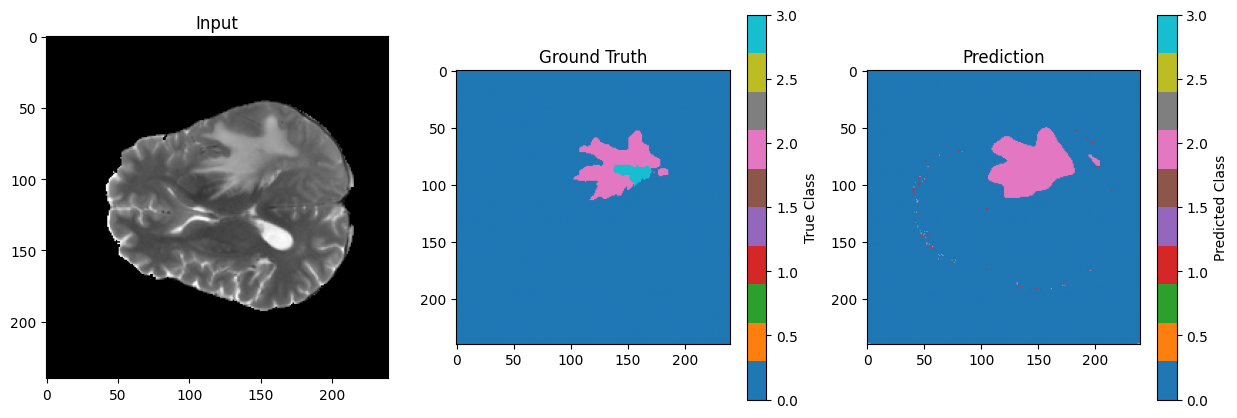

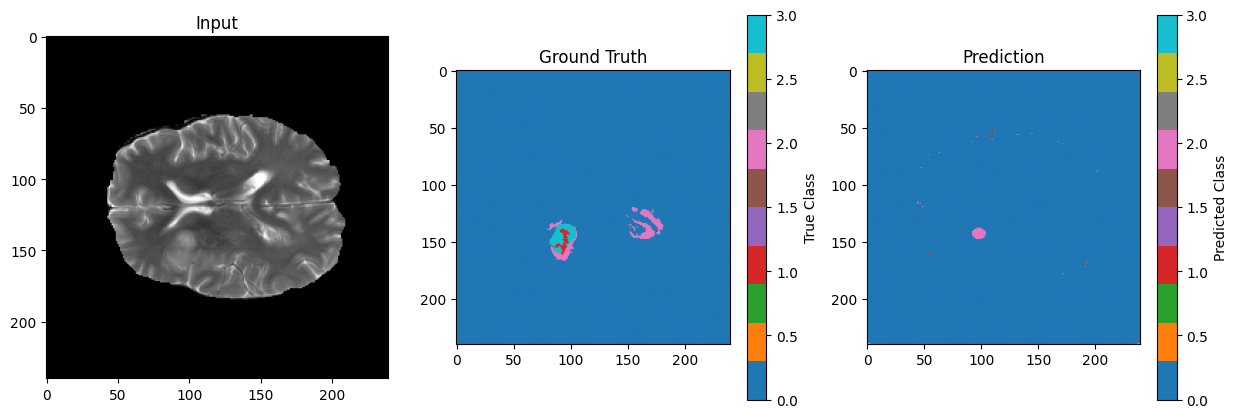

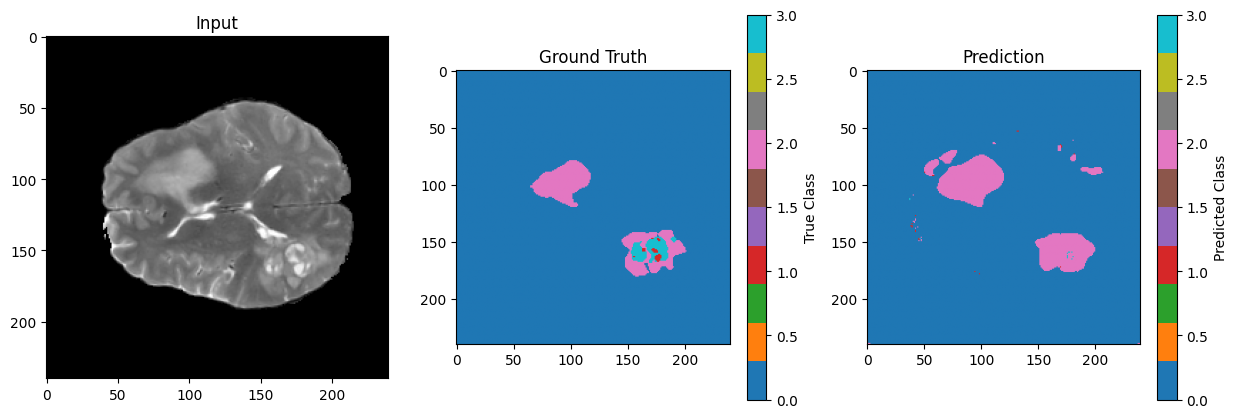

Test Dice Scores:
Background (0): 0.9917
Necrotic  (1): 0.3157
Edema     (2): 0.4894
Enhancing (3, originally label 4): 0.2503


In [47]:
# ============================================================
# Question 6: Multi-Class Segmentation
# ============================================================

def normalize_multiclass(input_image, input_mask, percentile=0.001, eps=1e-6):
    """
    Normalize the image to [0, 1] and preserve the original BraTS classes.

    BraTS labels:
        0 -> background
        1 -> necrotic / non-enhancing tumor core
        2 -> edema
        4 -> enhancing tumor

    For PyTorch CrossEntropyLoss we remap:
        4 -> 3
    so the final labels become {0, 1, 2, 3}.
    """
    if not isinstance(input_image, torch.Tensor):
        input_image = torch.tensor(input_image, dtype=torch.float32)

    img_array = input_image.contiguous().view(-1)
    min_img = torch.quantile(img_array, percentile)
    max_img = torch.quantile(img_array, 1 - percentile)
    img_normalized = (input_image - min_img) / (max_img - min_img + eps)
    img_normalized = torch.clamp(img_normalized, 0, 1).float()

    if not isinstance(input_mask, torch.Tensor):
        input_mask = torch.tensor(input_mask, dtype=torch.int64)
    else:
        input_mask = input_mask.to(torch.int64)

    mask_multiclass = input_mask.clone()
    mask_multiclass[mask_multiclass == 4] = 3

    return img_normalized, mask_multiclass


def create_numpy_arrays_multiclass(
    patient_ids,
    modalities=['t2'],
    slice_indices=[lambda d: d // 2],
    data_path=TRAIN_DATA_PATH,
):
    """
    Preprocess patient data into numpy arrays for multi-class segmentation.

    Returns:
        X: (N, H, W, C) float32
        Y: (N, H, W, 1) int64 with labels in {0,1,2,3}
    """
    all_images = []
    all_masks = []

    print(f"Preprocessing {len(patient_ids)} patients with {len(modalities)} modality(ies)...")

    for patient_id in tqdm(patient_ids, desc="Loading patients"):
        niftis_to_load = modalities + ['seg']
        pt_img_dict = read_patient_niftis(
            patient_id,
            niftis_to_load=niftis_to_load,
            data_path=data_path,
        )

        depth = pt_img_dict['seg'].shape[2]

        for slice_fn in slice_indices:
            slice_idx = slice_fn(depth)
            channels = []

            seg_slice = pt_img_dict['seg'].get_fdata()[:, :, slice_idx]

            for modality in modalities:
                mod_slice = pt_img_dict[modality].get_fdata()[:, :, slice_idx]
                img_normalized, mask_multiclass = normalize_multiclass(mod_slice, seg_slice)
                channels.append(img_normalized.cpu().numpy())

            if len(channels) == 1:
                img_multi = np.expand_dims(channels[0], axis=-1)
            else:
                img_multi = np.stack(channels, axis=-1)

            mask_np = mask_multiclass.cpu().numpy().astype(np.int64)
            mask_np = np.expand_dims(mask_np, axis=-1)

            all_images.append(img_multi)
            all_masks.append(mask_np)

    X = np.array(all_images, dtype=np.float32)
    Y = np.array(all_masks, dtype=np.int64)

    print(f"Preprocessing complete! Shape: {X.shape}")
    print(f"Memory usage: ~{X.nbytes / 1e6:.1f} MB (images) + {Y.nbytes / 1e6:.1f} MB (masks)")

    return X, Y


# Preprocess data for Question 6
X_train_q6, Y_train_q6 = create_numpy_arrays_multiclass(train_ids, modalities=['t2'])
X_val_q6, Y_val_q6 = create_numpy_arrays_multiclass(val_ids, modalities=['t2'])
X_test_q6, Y_test_q6 = create_numpy_arrays_multiclass(test_ids, modalities=['t2'])

# Create datasets and loaders
train_dataset_q6 = TensorDataset(
    torch.from_numpy(X_train_q6).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_train_q6).permute(0, 3, 1, 2).long(),
)
val_dataset_q6 = TensorDataset(
    torch.from_numpy(X_val_q6).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_val_q6).permute(0, 3, 1, 2).long(),
)
test_dataset_q6 = TensorDataset(
    torch.from_numpy(X_test_q6).permute(0, 3, 1, 2).float(),
    torch.from_numpy(Y_test_q6).permute(0, 3, 1, 2).long(),
)

Q6_BATCH_SIZE = 64
train_loader_q6 = DataLoader(train_dataset_q6, batch_size=Q6_BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_q6 = DataLoader(val_dataset_q6, batch_size=Q6_BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_q6 = DataLoader(test_dataset_q6, batch_size=Q6_BATCH_SIZE, shuffle=False, num_workers=2)


class UNetMultiClass(nn.Module):
    """
    U-Net for multi-class semantic segmentation.

    Returns raw logits of shape (N, 4, H, W).
    No sigmoid is applied because CrossEntropyLoss expects logits.
    """
    def __init__(self, in_channels=1, out_channels=4):
        super(UNetMultiClass, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
            )

        self.down1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.center = conv_block(512, 1024)

        self.up4 = conv_block(1024 + 512, 512)
        self.up3 = conv_block(512 + 256, 256)
        self.up2 = conv_block(256 + 128, 128)
        self.up1 = conv_block(128 + 64, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        down1 = self.down1(x)
        pool1 = self.pool1(down1)

        down2 = self.down2(pool1)
        pool2 = self.pool2(down2)

        down3 = self.down3(pool2)
        pool3 = self.pool3(down3)

        down4 = self.down4(pool3)
        pool4 = self.pool4(down4)

        center = self.center(pool4)

        up4 = F.interpolate(center, scale_factor=2, mode='bilinear', align_corners=True)
        up4 = torch.cat([up4, down4], dim=1)
        up4 = self.up4(up4)

        up3 = F.interpolate(up4, scale_factor=2, mode='bilinear', align_corners=True)
        up3 = torch.cat([up3, down3], dim=1)
        up3 = self.up3(up3)

        up2 = F.interpolate(up3, scale_factor=2, mode='bilinear', align_corners=True)
        up2 = torch.cat([up2, down2], dim=1)
        up2 = self.up2(up2)

        up1 = F.interpolate(up2, scale_factor=2, mode='bilinear', align_corners=True)
        up1 = torch.cat([up1, down1], dim=1)
        up1 = self.up1(up1)

        return self.final(up1)  # logits


def dice_per_class(y_true, y_pred, num_classes=4):
    """
    Compute Dice score separately for each class.
    y_true and y_pred must contain integer class IDs of shape (N, H, W).
    """
    dice_scores = []
    for c in range(num_classes):
        true_c = (y_true == c).float()
        pred_c = (y_pred == c).float()
        dice_c = dice_coef(true_c, pred_c)
        dice_scores.append(dice_c.item())
    return dice_scores


def train_model_q6(model, train_loader, val_loader, num_epochs=20, learning_rate=1e-4, use_gpu=True):
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    metrics = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_dice_bg': [],
        'val_dice_necrotic': [],
        'val_dice_edema': [],
        'val_dice_enhancing': [],
    }

    print("=" * 60)
    print(f"Training on: {device}")
    print(f"Epochs: {num_epochs} | Learning Rate: {learning_rate} | Batch Size: {train_loader.batch_size}")
    print("=" * 60)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=False):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)                       # (N, 4, H, W)
            masks_prepared = masks.squeeze(1).long()     # (N, H, W)

            loss = criterion(outputs, masks_prepared)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        all_val_preds = []
        all_val_targets = []

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                masks_prepared = masks.squeeze(1).long()
                loss = criterion(outputs, masks_prepared)
                running_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                all_val_preds.append(preds.cpu())
                all_val_targets.append(masks_prepared.cpu())

        val_loss = running_val_loss / len(val_loader)

        val_preds_cat = torch.cat(all_val_preds, dim=0)
        val_targets_cat = torch.cat(all_val_targets, dim=0)
        val_dice_scores = dice_per_class(val_targets_cat, val_preds_cat, num_classes=4)

        metrics['epoch'].append(epoch + 1)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        metrics['val_dice_bg'].append(val_dice_scores[0])
        metrics['val_dice_necrotic'].append(val_dice_scores[1])
        metrics['val_dice_edema'].append(val_dice_scores[2])
        metrics['val_dice_enhancing'].append(val_dice_scores[3])

        print(
            f"Epoch {epoch + 1:2d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Dice [BG={val_dice_scores[0]:.3f}, Nec={val_dice_scores[1]:.3f}, "
            f"Edema={val_dice_scores[2]:.3f}, Enh={val_dice_scores[3]:.3f}]"
        )

    return pd.DataFrame(metrics)


model_q6 = UNetMultiClass(in_channels=1, out_channels=4)
metrics_q6 = train_model_q6(model_q6, train_loader_q6, val_loader_q6, num_epochs=20, use_gpu=True)
display(metrics_q6.tail())

# Visualize a few test predictions
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_q6.eval()

with torch.no_grad():
    for images, masks in test_loader_q6:
        images = images.to(device)
        outputs = model_q6(images)
        pred_class = torch.argmax(outputs, dim=1)

        num_examples = min(3, images.shape[0])
        for i in range(num_examples):
            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(images[i, 0].cpu(), cmap='gray')
            plt.title('Input')

            plt.subplot(1, 3, 2)
            plt.imshow(masks[i, 0].cpu(), cmap='tab10', vmin=0, vmax=3)
            plt.colorbar(label='True Class')
            plt.title('Ground Truth')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_class[i].cpu(), cmap='tab10', vmin=0, vmax=3)
            plt.colorbar(label='Predicted Class')
            plt.title('Prediction')

            plt.show()
        break

# Final test-set per-class Dice
all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for images, masks in test_loader_q6:
        images = images.to(device)
        outputs = model_q6(images)
        preds = torch.argmax(outputs, dim=1)

        all_test_preds.append(preds.cpu())
        all_test_targets.append(masks.squeeze(1).cpu().long())

test_preds_cat = torch.cat(all_test_preds, dim=0)
test_targets_cat = torch.cat(all_test_targets, dim=0)
test_dice_scores = dice_per_class(test_targets_cat, test_preds_cat, num_classes=4)

print("Test Dice Scores:")
print(f"Background (0): {test_dice_scores[0]:.4f}")
print(f"Necrotic  (1): {test_dice_scores[1]:.4f}")
print(f"Edema     (2): {test_dice_scores[2]:.4f}")
print(f"Enhancing (3, originally label 4): {test_dice_scores[3]:.4f}")

Edema was the easiest tumor region to segment, while enhancing tumor was the hardest. The test Dice scores were edema = 0.4894, necrotic = 0.3157, and enhancing = 0.2503.

The tradeoff versus binary whole-tumor segmentation is that binary segmentation is easier and usually achieves better overall Dice because all tumor tissue is merged into a single foreground class. In contrast, multi-class segmentation is more difficult because it must distinguish among multiple subregions, but it provides more clinically useful detail about tumor composition.

---

### Question 7: Reflection [2 points]

Write a brief reflection addressing:

1. **Learning**: Key insights about semantic segmentation and medical imaging
2. **Challenges**: Most difficult aspects of the experiments

This notebook showed me that semantic segmentation in medical imaging is highly sensitive to preprocessing, MRI modality choice, and class definition. The baseline binary model could usually locate the tumor, but it still produced smooth boundaries, false positives, and false negatives. The experiments showed that modality matters: FLAIR outperformed the T2 baseline, and the best multi-modal combination was T1 + T1CE + FLAIR. At the same time, more input did not always help, since using three slices per patient and using all four modalities did not produce the best results. The multi-class experiment was the clearest example of the real difficulty of the task: segmenting tumor subregions was much harder than segmenting whole tumor, especially for smaller or less distinct regions like enhancing tumor. The biggest challenge was dealing with class imbalance, heterogeneous MRI appearance, and the fact that correct coarse localization is much easier than precise boundary and subregion segmentation.

---

## Additional Resources

- Batch vs Epoch: https://machinelearningmastery.com/difference-between-a-batch-and-an-epoch/

- Automating hyperparameter tuning: https://neptune.ai/blog/hyperparameter-tuning-in-python-complete-guide

- Why is image normalizaton needed: https://arthurdouillard.com/post/normalization/

Good luck with your learning!